<a href="https://colab.research.google.com/github/miguelbm03-hub/TFM_BallesterosMiguel/blob/main/TFM_Anexos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Anexo A. Preparación y limpieza del conjunto de datos de incidencias urbanas

## A.1. Objetivo de la preparación de datos

En esta fase se construye un conjunto de datos estructurado a partir de un fichero CSV de incidencias urbanas procedente de datos abiertos municipales. El objetivo es transformar registros heterogéneos en una tabla normalizada que pueda utilizarse posteriormente en las tareas de clasificación automática, priorización y evaluación del sistema multi-agente propuesto en el TFM.

El proceso incluye:

- Lectura robusta del fichero original.
- Extracción de campos mediante expresiones regulares.
- Conversión de tipos de datos.
- Generación de variables derivadas.
- Validación básica de registros.
- Exportación del dataset limpio para su uso posterior.


In [ ]:
from pathlib import Path
import pandas as pd
import re

## A.2. Lectura del fichero original

El fichero original presenta un formato parcialmente inconsistente, con mezcla de separadores (`;` y `,`) y campos textuales no estructurados. Por este motivo se realiza una lectura línea a línea, lo que permite aplicar un proceso de *parsing* personalizado y más robusto que la lectura estándar mediante `pandas.read_csv()`.


In [ ]:
# Ruta del fichero CSV original
csv_path = Path('2026.csv')

# Lectura completa del fichero como texto
lines = csv_path.read_text(
    encoding='utf-8',
    errors='ignore'
).splitlines()

print(f'Total de líneas leídas: {len(lines)}')

Total de líneas leídas: 18794


## A.3. Definición de estructuras auxiliares

Se inicializan dos listas:

- **`parsed`**: almacenará los registros correctamente procesados.
- **`failed`**: almacenará las líneas que no puedan interpretarse correctamente, permitiendo una posterior inspección manual.

Además, se define un patrón de fecha con precisión de milisegundos mediante expresiones regulares.


In [ ]:
# Registros válidos y fallidos
parsed = []
failed = []

# Patrón de fecha: YYYY-MM-DD HH:MM:SS.mmm
date_pat = r'\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2}\.\d{3}'

## A.4. Extracción de campos mediante expresiones regulares

Cada línea se procesa de forma secuencial. El procedimiento aplicado es el siguiente:

1. Se eliminan los espacios en blanco y las líneas vacías.
2. Se identifican las dos fechas principales del registro (registro y resolución).
3. Se extrae el código de incidencia.
4. Se obtiene la prioridad.
5. Se localizan las coordenadas geográficas (longitud y latitud).
6. Se separan la dirección, el tipo de incidencia y el responsable.
7. Los registros que no cumplen la estructura esperada se almacenan en la lista **`failed`**.


In [ ]:
for idx, line in enumerate(lines):

    line = line.strip()

    # Ignorar líneas vacías y cabeceras
    if not line or line.startswith('CODIGO;'):
        continue

    # Buscar fechas
    dates = re.findall(date_pat, line)

    if len(dates) < 2:
        failed.append((idx + 1, line[:120]))
        continue

    fecha_registro = dates[0]
    fecha_resolucion = dates[1]

    # Extraer código
    codigo = line.split(fecha_registro)[0].rstrip(',; ')

    # Resto del contenido
    rest = line.split(fecha_resolucion, 1)[1].lstrip(',; ')

    # Extraer prioridad
    if ',' not in rest:
        failed.append((idx + 1, line[:120]))
        continue

    prioridad, rest = rest.split(',', 1)
    prioridad = prioridad.strip()

    # Extraer coordenadas
    nums = re.findall(r'-?\d+(?:\.\d+)?', rest)

    if len(nums) < 2:
        failed.append((idx + 1, line[:120]))
        continue

    longitud = nums[-2]
    latitud = nums[-1]

    # Separar por coordenadas
    coord_pattern = re.escape(longitud) + r'[;,]' + re.escape(latitud)
    parts = re.split(coord_pattern, rest, maxsplit=1)

    if len(parts) != 2:
        failed.append((idx + 1, line[:120]))
        continue

    before_coords, after_coords = parts

    # Dirección
    direccion = before_coords.rsplit(',', 1)[0].strip(' ,;')

    # Tipo y responsable
    after_coords = after_coords.strip(' ,;')

    if ',' in after_coords:
        tipo, responsable = after_coords.rsplit(',', 1)
    else:
        tipo, responsable = after_coords, ''

    # Guardar registro
    parsed.append({
        'codigo': codigo.strip(),
        'fecha_registro': fecha_registro,
        'fecha_resolucion': fecha_resolucion,
        'prioridad': prioridad,
        'direccion': direccion,
        'longitud': longitud,
        'latitud': latitud,
        'tipo': tipo.strip(),
        'responsable': responsable.strip(),
    })

## A.5. Construcción del conjunto de datos estructurado

Los registros válidos se transforman en un **DataFrame** de `pandas`, que constituye la representación tabular principal del conjunto de datos (*dataset*).


In [ ]:
df = pd.DataFrame(parsed)

print(f'Registros válidos: {len(df)}')
print(f'Registros fallidos: {len(failed)}')

df.head()

Registros válidos: 15923
Registros fallidos: 2870


,codigo,fecha_registro,fecha_resolucion,prioridad,direccion,longitud,latitud,tipo,responsable
0,DIST-1154939,2025-11-25 09:08:10.697,2026-01-01 23:00:06.000,Media,CL QUITERIA 4,373603.45336002298,4067623.1918764999,Contenedor orgnica - Manchas/Sucio,LIMASAM
1,900-1159030,2025-12-18 10:03:20.263,2026-01-01 23:00:04.000,Media,PL ARROYO 8,378736.93577996898,4065007.1940170801,Aceras - Muebles,LIMASAM
2,900-1159053,2025-12-18 11:25:05.107,2026-01-01 23:00:05.000,Media,CL HERNANDO DE SOTO 6,370827.08650425798,4064031.6873023999,Aceras - Muebles,LIMASAM
3,900-1159079,2025-12-18 12:40:40.700,2026-01-01 23:00:05.000,Media,CL ALTABACA 18,376893.15735934302,4066851.15118034,Aceras - Podas,LIMASAM
4,900-1159204,2025-12-19 09:14:47.147,2026-01-01 23:00:05.000,Media,CL FRANCISCO PACHECO 11,370665.26517996402,4061613.8282063198,Aceras - Muebles,LIMASAM


## A.6. Conversión de tipos de datos

Las variables temporales se convierten al tipo `datetime`, mientras que las coordenadas geográficas se convierten a formato numérico (`float`). Esto permite realizar posteriormente análisis temporales y espaciales.


In [ ]:
# Fechas
for c in ['fecha_registro', 'fecha_resolucion']:
    df[c] = pd.to_datetime(df[c], errors='coerce')

# Coordenadas
for c in ['longitud', 'latitud']:
    df[c] = pd.to_numeric(df[c], errors='coerce')

df.dtypes

,0
codigo,object
fecha_registro,datetime64[ns]
fecha_resolucion,datetime64[ns]
prioridad,object
direccion,object
longitud,float64
latitud,float64
tipo,object
responsable,object


## A.7. Generación de variables derivadas

Se generan dos variables adicionales:

- **`texto_incidencia`**: concatenación del tipo de incidencia y la dirección, útil para tareas de procesamiento del lenguaje natural.
- **`dias_resolucion`**: tiempo transcurrido entre el registro y la resolución de la incidencia, expresado en días.

Esta última variable será especialmente relevante para el análisis de priorización y eficiencia operativa.


In [ ]:
# Texto consolidado para NLP
df['texto_incidencia'] = (
    df['tipo'] + ' en ' + df['direccion']
)

# Tiempo de resolución en días
df['dias_resolucion'] = (
    df['fecha_resolucion'] - df['fecha_registro']
).dt.total_seconds() / 86400

df[['texto_incidencia', 'dias_resolucion']].head()

,texto_incidencia,dias_resolucion
0,Contenedor orgnica - Manchas/Sucio en CL QUITE...,37.577723
1,Aceras - Muebles en PL ARROYO 8,14.539395
2,Aceras - Muebles en CL HERNANDO DE SOTO 6,14.482638
3,Aceras - Podas en CL ALTABACA 18,14.430142
4,Aceras - Muebles en CL FRANCISCO PACHECO 11,13.573123


A.8. Exportación del conjunto de datos limpio

El conjunto de datos estructurado se exporta en formato CSV con codificación UTF-8 y marca BOM (utf-8-sig), lo que facilita su apertura correcta en herramientas como Microsoft Excel y Power BI.

In [ ]:
out_path = Path('incidencias_malaga_limpio.csv')

df.to_csv(
    out_path,
    index=False,
    encoding='utf-8-sig'
)

print(f'Archivo guardado en: {out_path.resolve()}')

Archivo guardado en: /content/incidencias_malaga_limpio.csv


## A.9. Validación básica y estadísticas descriptivas

Finalmente, se realiza una validación preliminar del conjunto de datos mediante las siguientes comprobaciones:

- Número de registros procesados.
- Distribución de prioridades.
- Categorías de incidencias más frecuentes.
- Visualización de ejemplos representativos.

Estas verificaciones permiten detectar posibles anomalías y comprobar que el proceso de *parsing* ha producido un conjunto de datos coherente y consistente para su utilización en las fases posteriores del trabajo.


In [ ]:
print('=' * 60)
print('RESUMEN DEL PROCESAMIENTO')
print('=' * 60)

print(f'Registros válidos : {len(df)}')
print(f'Registros fallidos: {len(failed)}')

print('\nColumnas del dataset:')
print(df.columns.tolist())

print('\nDistribución de prioridades:')
print(df['prioridad'].value_counts())

print('\nTop 10 tipos de incidencia:')
print(df['tipo'].value_counts().head(10))

print('\nTiempo medio de resolución (días):')
print(round(df['dias_resolucion'].mean(), 2))

print('\nEjemplos de incidencias:')
print(
    df[['texto_incidencia', 'prioridad']]
    .head(5)
    .to_string(index=False)
)

RESUMEN DEL PROCESAMIENTO
Registros válidos : 15923
Registros fallidos: 2870

Columnas del dataset:
['codigo', 'fecha_registro', 'fecha_resolucion', 'prioridad', 'direccion', 'longitud', 'latitud', 'tipo', 'responsable', 'texto_incidencia', 'dias_resolucion']

Distribución de prioridades:
prioridad
Media      11010
Baja        3228
Urgente     1460
Alta         225
Name: count, dtype: int64

Top 10 tipos de incidencia:
tipo
Aceras - Muebles                                         2706
Aceras - Basura                                          2486
Aceras - Manchas                                         1510
Aceras - Podas                                           1052
Llamada de atenciÃ³n - Recogida                           972
Limpieza - AcumulaciÃ³n importante de basura en calle     903
Llamada de atenciÃ³n - Limpieza                           793
Aceras - ElectrodomÃ©sticos                               744
Papeleras - Llena                                         350
Aceras - Excre

## A.10. Resultado de la fase de preparación

El resultado de esta fase es un conjunto de datos estructurado y validado que contiene, para cada incidencia:

- Identificador único.
- Fechas de registro y resolución.
- Nivel de prioridad.
- Dirección.
- Coordenadas geográficas.
- Tipo de incidencia.
- Responsable asignado.
- Descripción textual consolidada.
- Tiempo de resolución.

Este conjunto de datos constituye la base experimental sobre la que se desarrollarán las siguientes fases del TFM: la generación de etiquetas de referencia, la clasificación automática mediante modelos de lenguaje y la evaluación comparativa entre el sistema multiagente y el enfoque monolítico.


## A.9.1. Interpretación de los resultados obtenidos

El proceso de limpieza y estructuración produjo un conjunto de datos con **15.923 incidencias válidas** y **11 variables relevantes** para el análisis posterior. Las variables incluyen información temporal, espacial y descriptiva de cada incidencia, así como una variable derivada correspondiente al tiempo de resolución.

La distribución de prioridades muestra un claro predominio de incidencias de prioridad **Media** (`11.010 registros`), seguidas de **Baja** (`3.228 registros`), **Urgente** (`1.460 registros`) y **Alta** (`225 registros`). Esta distribución evidencia un importante desbalance de clases, aspecto que deberá tenerse en cuenta en las fases posteriores de clasificación automática.

Las categorías de incidencias más frecuentes están relacionadas con problemas de limpieza y mantenimiento urbano, destacando:

- **Aceras - Muebles**: `2.706 incidencias`.
- **Aceras - Basura**: `2.486 incidencias`.
- **Aceras - Manchas**: `1.510 incidencias`.
- **Aceras - Podas**: `1.052 incidencias`.

Estas categorías representan una parte significativa del volumen total de incidencias y constituyen candidatos naturales para las tareas de clasificación temática del sistema multi-agente.

El análisis preliminar del tiempo de resolución mostró una **mediana de aproximadamente 9,5 días**, mientras que la **media alcanzó 23,7 días**. La diferencia entre ambas medidas indica una distribución fuertemente asimétrica, probablemente causada por la existencia de incidencias con tiempos de resolución extremadamente elevados o por la presencia de registros inconsistentes.

Asimismo, se detectaron valores negativos en la variable **`dias_resolucion`**, lo que indica que algunas incidencias presentan una fecha de resolución anterior a la fecha de registro. Estos casos se consideran anomalías y serán tratados en una fase posterior de validación y depuración del conjunto de datos.


In [ ]:
# Incidencias con tiempo de resolución negativo
negativas = df[df['dias_resolucion'] < 0]

# Incidencias con tiempos extremadamente altos (> 365 días)
extremas = df[df['dias_resolucion'] > 365]

print('=' * 60)
print('ANÁLISIS DE ANOMALÍAS')
print('=' * 60)

print(f'Incidencias con tiempo negativo : {len(negativas)}')
print(f'Incidencias con tiempo > 365 días: {len(extremas)}')

if len(negativas) > 0:
    print('\nEjemplos de tiempos negativos:')
    print(
        negativas[['codigo', 'fecha_registro',
                   'fecha_resolucion', 'dias_resolucion']]
        .head(5)
        .to_string(index=False)
    )

if len(extremas) > 0:
    print('\nEjemplos de tiempos extremos:')
    print(
        extremas[['codigo', 'dias_resolucion']]
        .sort_values('dias_resolucion', ascending=False)
        .head(5)
        .to_string(index=False)
    )

ANÁLISIS DE ANOMALÍAS
Incidencias con tiempo negativo : 228
Incidencias con tiempo > 365 días: 110

Ejemplos de tiempos negativos:
      codigo          fecha_registro fecha_resolucion  dias_resolucion
 900-1160834 2026-01-05 10:56:47.377       2026-01-05        -0.456104
 900-1160836 2026-01-05 11:04:05.177       2026-01-05        -0.461171
 900-1161357 2026-01-08 10:28:04.797       2026-01-08        -0.436167
MlgF-1161916 2026-01-11 17:15:04.377       2026-01-11        -0.718801
 900-1161992 2026-01-12 09:13:45.433       2026-01-12        -0.384554

Ejemplos de tiempos extremos:
    codigo  dias_resolucion
DIST-91101      6339.996458
URB-109368      6150.859379
URB-109381      6150.840104
POL-471160      3430.949224
STL-752715      1974.158274


A.9.2. Tratamiento de registros anómalos

Con el objetivo de garantizar la calidad del conjunto de datos utilizado en los experimentos, se identificaron y documentaron dos tipos principales de anomalías:

Tiempos de resolución negativos, originados por inconsistencias entre las fechas de registro y resolución.

Tiempos de resolución extremadamente altos, superiores a 365 días, que podrían corresponder a incidencias históricas, registros cerrados de forma masiva o errores de captura.

En esta fase inicial, dichos registros se conservan para su análisis y trazabilidad. No obstante, para los experimentos de evaluación del sistema multi-agente se considerará la creación de una versión depurada del dataset excluyendo los casos claramente inconsistentes, con el fin de evitar sesgos en el cálculo de métricas operativas.

# **Anexo B. Análisis exploratorio del conjunto de datos**

## **B.1. Objetivo del análisis exploratorio**

El objetivo de esta fase es caracterizar el comportamiento general del conjunto de datos y detectar patrones relevantes para el diseño del sistema de clasificación y priorización automática de incidencias.

El análisis se centra en:

* **Distribución temporal** de incidencias.
* **Distribución de prioridades**.
* **Categorías de incidencias** más frecuentes.
* **Tiempos de resolución**.
* **Relaciones entre prioridad y duración** de resolución.

> **Nota:** Las figuras generadas se exportan en alta resolución para su posible inclusión directa en la memoria del TFM.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Estilo académico
sns.set_theme(style="whitegrid", font_scale=1.1)

# Crear carpeta para guardar figuras
Path("figuras").mkdir(exist_ok=True)

print("Carpeta 'figuras' creada correctamente.")

Carpeta 'figuras' creada correctamente.


## **B.2. Preparación de variables temporales**

Se generan variables auxiliares correspondientes al año y al mes de registro de cada incidencia, lo que permitirá realizar análisis de evolución temporal y estacionalidad.



In [ ]:
df["año"] = df["fecha_registro"].dt.year
df["mes"] = df["fecha_registro"].dt.month

# Nombre del mes para gráficos
meses = {1: "Ene", 2: "Feb", 3: "Mar", 4: "Abr",
    5: "May", 6: "Jun", 7: "Jul", 8: "Ago",
    9: "Sep", 10: "Oct", 11: "Nov", 12: "Dic"
}

df["mes_nombre"] = df["mes"].map(meses)

df[["fecha_registro", "año", "mes", "mes_nombre"]].head()

,fecha_registro,año,mes,mes_nombre
0,2025-11-25 09:08:10.697,2025,11,Nov
1,2025-12-18 10:03:20.263,2025,12,Dic
2,2025-12-18 11:25:05.107,2025,12,Dic
3,2025-12-18 12:40:40.700,2025,12,Dic
4,2025-12-19 09:14:47.147,2025,12,Dic


## **B.3. Distribución temporal de incidencias**

La siguiente figura muestra el número de incidencias registradas por mes. Este análisis permite identificar posibles patrones estacionales o periodos de mayor actividad ciudadana.

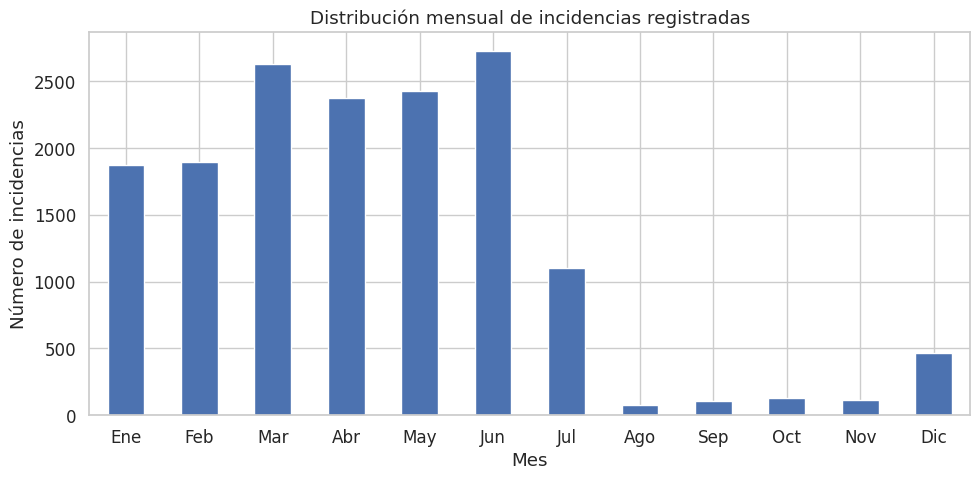

In [ ]:
plt.figure(figsize=(10, 5))

orden_meses = ["Ene","Feb","Mar","Abr","May","Jun",
               "Jul","Ago","Sep","Oct","Nov","Dic"]

conteo_meses = (
    df["mes_nombre"]
    .value_counts()
    .reindex(orden_meses)
)

conteo_meses.plot(kind="bar")

plt.title("Distribución mensual de incidencias registradas")
plt.xlabel("Mes")
plt.ylabel("Número de incidencias")
plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig(
    "figuras/fig_B1_incidencias_mes.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### **Interpretación de la Figura B.1**

La distribución mensual permite evaluar la existencia de estacionalidad en la generación de incidencias urbanas. Un incremento de incidencias en determinados meses podría estar relacionado con factores climáticos, periodos vacacionales o variaciones en la actividad urbana. En este caso, la mayoría de datos son de 2026, y al momento de escribir esto estamos en julio, por lo que no hay datos del resto del año todavía.

## **B.4. Distribución de prioridades**

El análisis de la prioridad asignada a las incidencias es especialmente relevante para el diseño del agente de priorización, ya que permite conocer el grado de desbalance existente entre clases.

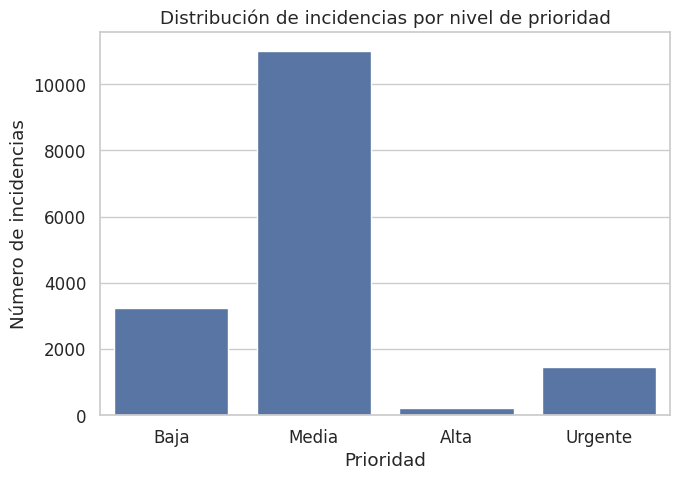

In [ ]:
plt.figure(figsize=(7, 5))

orden_prioridad = ["Baja", "Media", "Alta", "Urgente"]

sns.countplot(
    data=df,
    x="prioridad",
    order=orden_prioridad
)

plt.title("Distribución de incidencias por nivel de prioridad")
plt.xlabel("Prioridad")
plt.ylabel("Número de incidencias")

plt.tight_layout()
plt.savefig(
    "figuras/fig_B2_prioridades.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### **Interpretación de la Figura B.2**

La figura muestra un claro **predominio de incidencias de prioridad Media**, lo que evidencia un desbalance significativo entre clases. Este aspecto deberá considerarse en la fase de entrenamiento y evaluación de los modelos de clasificación, pudiendo requerir:

* **Técnicas de ponderación de clases** (*class weighting*).
* **Muestreo estratificado** (*stratified sampling*).

## **B.5. Tipos de incidencias más frecuentes**

Se identifican las categorías de incidencias con mayor frecuencia de aparición, lo que permite caracterizar los problemas urbanos predominantes en el conjunto de datos.

/tmp/ipykernel_1086/2114910439.py:14: UserWarning: Glyph 129 (\x81) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1086/2114910439.py:15: UserWarning: Glyph 129 (\x81) missing from font(s) DejaVu Sans.
  plt.savefig(
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129 (\x81) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


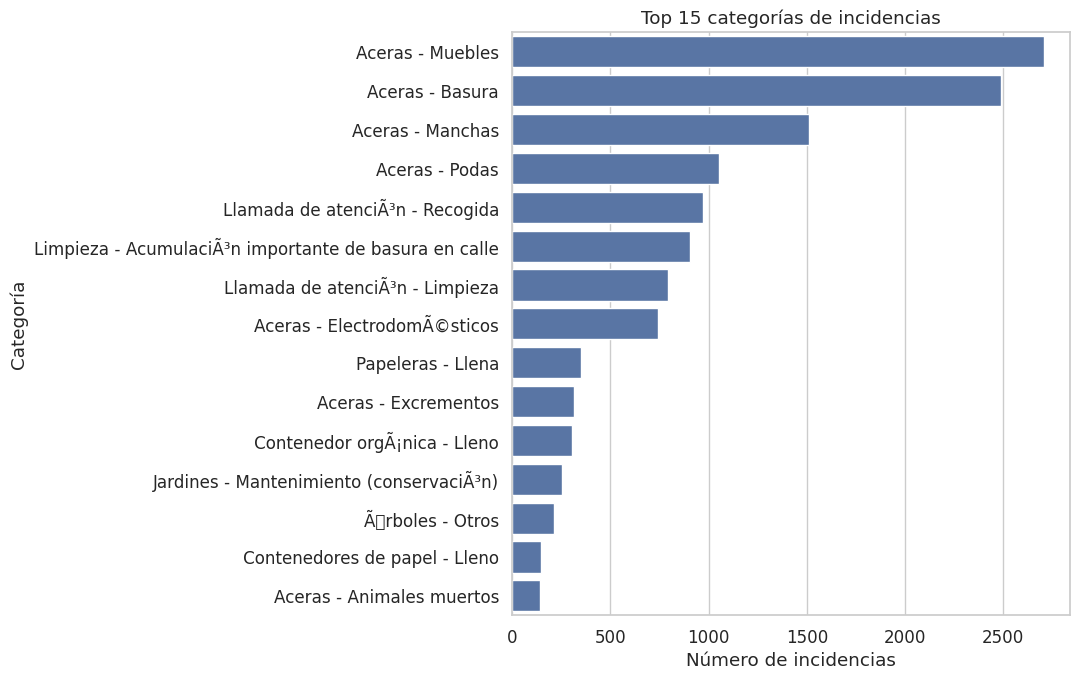

In [ ]:
top_tipos = df["tipo"].value_counts().head(15)

plt.figure(figsize=(11, 7))

sns.barplot(
    x=top_tipos.values,
    y=top_tipos.index
)

plt.title("Top 15 categorías de incidencias")
plt.xlabel("Número de incidencias")
plt.ylabel("Categoría")

plt.tight_layout()
plt.savefig(
    "figuras/fig_B3_top_categorias.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### **Interpretación de la Figura B.3**

Las incidencias relacionadas con limpieza y mantenimiento de aceras constituyen la mayor parte del volumen total registrado. Este resultado sugiere que dichas categorías serán especialmente relevantes para el diseño del agente de clasificación temática, ya que concentran una parte significativa de los casos que deberá procesar el sistema.

## **B.6. Distribución del tiempo de resolución**

Debido a la presencia de valores extremos y anomalías, se representa la distribución del tiempo de resolución utilizando únicamente valores comprendidos entre 0 y 100 días.

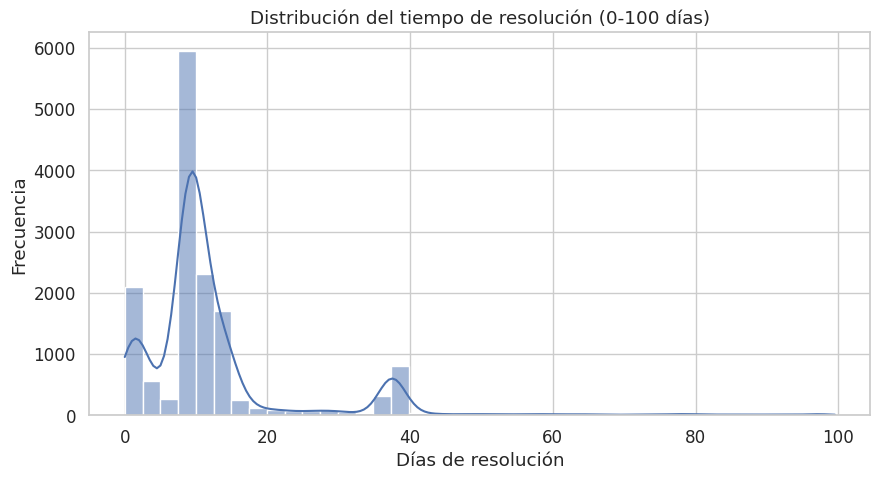

In [ ]:
df_res = df[
    (df["dias_resolucion"] >= 0) &
    (df["dias_resolucion"] <= 100)
]

plt.figure(figsize=(9, 5))

sns.histplot(
    df_res["dias_resolucion"],
    bins=40,
    kde=True
)

plt.title("Distribución del tiempo de resolución (0-100 días)")
plt.xlabel("Días de resolución")
plt.ylabel("Frecuencia")

plt.tight_layout()
plt.savefig(
    "figuras/fig_B4_tiempo_resolucion.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### **Interpretación de la Figura B.4**

La distribución presenta una fuerte asimetría positiva: la mayoría de las incidencias se resuelven en un intervalo relativamente corto, mientras que un número reducido de casos permanece abierto durante periodos considerablemente más largos. Este comportamiento es habitual en datos operativos de servicios públicos y justifica el uso de medidas robustas como la mediana.

## **B.7. Relación entre prioridad y tiempo de resolución**

Se analiza la relación entre el nivel de prioridad y el tiempo de resolución mediante diagramas de caja, lo que permite comparar la distribución de tiempos entre diferentes niveles de urgencia.

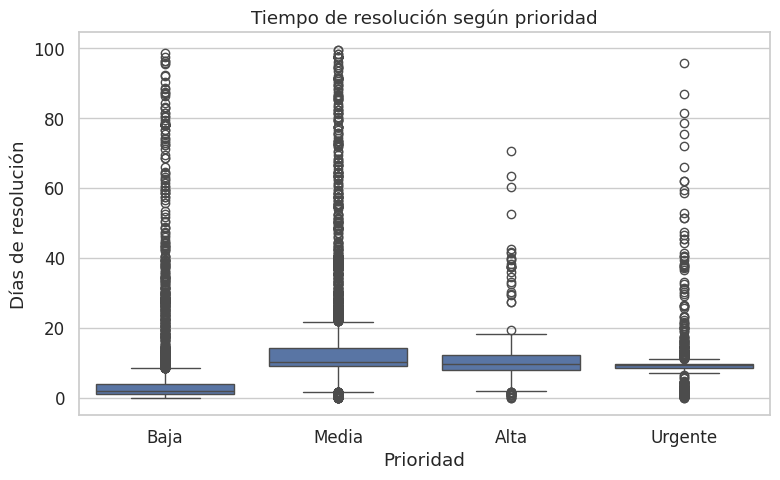

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_res,
    x="prioridad",
    y="dias_resolucion",
    order=["Baja", "Media", "Alta", "Urgente"]
)

plt.title("Tiempo de resolución según prioridad")
plt.xlabel("Prioridad")
plt.ylabel("Días de resolución")

plt.tight_layout()
plt.savefig(
    "figuras/fig_B5_boxplot_prioridad.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### **Interpretación de la Figura B.5**

Este análisis permite comprobar si las incidencias clasificadas como **Urgentes** o **Altas** son efectivamente resueltas en menos tiempo que las incidencias de menor prioridad. Si se observa una reducción significativa de la mediana de resolución en las categorías más urgentes, ello constituiría una evidencia de coherencia operativa en el proceso de gestión municipal.

## **B.8. Resumen estadístico del tiempo de resolución**

Se presenta un resumen descriptivo del tiempo de resolución utilizando medidas de tendencia central y dispersión.

In [ ]:
resumen = df_res["dias_resolucion"].describe()

print("=" * 60)
print("RESUMEN ESTADÍSTICO DEL TIEMPO DE RESOLUCIÓN")
print("=" * 60)

print(resumen)

print("\nMediana:", round(df_res["dias_resolucion"].median(), 2), "días")
print("Percentil 90:", round(df_res["dias_resolucion"].quantile(0.90), 2), "días")
print("Percentil 95:", round(df_res["dias_resolucion"].quantile(0.95), 2), "días")

RESUMEN ESTADÍSTICO DEL TIEMPO DE RESOLUCIÓN
count    15132.000000
mean        12.674849
std         12.548712
min          0.002728
25%          8.321898
50%          9.504715
75%         12.602006
max         99.530614
Name: dias_resolucion, dtype: float64

Mediana: 9.5 días
Percentil 90: 33.51 días
Percentil 95: 37.52 días


### **Interpretación del tiempo de resolución**

El análisis descriptivo del tiempo de resolución se realizó sobre **15.132 incidencias** con valores comprendidos entre **0 y 100 días**, excluyendo registros anómalos previamente identificados.

Las principales métricas obtenidas fueron las siguientes:

| Métrica | Valor |
| :--- | :--- |
| **Número de incidencias** | 15.132 |
| **Media** | 12,67 días |
| **Mediana** | 9,50 días |
| **Desviación estándar** | 12,55 días |
| **Percentil 25** | 8,32 días |
| **Percentil 75** | 12,60 días |
| **Percentil 90** | 33,51 días |
| **Percentil 95** | 37,52 días |
| **Máximo observado** | 99,53 días |

---

#### Análisis del comportamiento de la distribución

* **Asimetría positiva:** La diferencia entre la media (12,67 días) y la mediana (9,50 días) indica una asimetría positiva moderada. La mayoría de las incidencias se resuelven en un periodo relativamente corto, mientras que un conjunto reducido de casos presenta tiempos de resolución significativamente más elevados.
* **Estabilidad operativa base:** El **50 %** de las incidencias se resuelven en menos de 9,5 días, y el **75 %** antes de 12,6 días, lo que sugiere un comportamiento operativo relativamente estable para la mayor parte de los casos.
* **Cola de distribución:** Los percentiles superiores muestran un subconjunto con resolución más lenta:
  * El **10 %** de las incidencias supera los 33,5 días.
  * El **5 %** supera los 37,5 días.

> **Implicación práctica:** La desviación estándar (12,55 días) es muy similar a la media, lo que confirma una dispersión considerable en los tiempos de resolución. Esto refuerza la necesidad de utilizar medidas robustas (mediana y percentiles) y resulta un factor crítico para el diseño y evaluación del agente de priorización.

## **B.9 Función de distribución acumulada (CDF) del tiempo de resolución**

Para complementar el análisis descriptivo y visualizar la proporción acumulada de incidencias en función del tiempo de resolución, se calculó y representó la **Función de Distribución Acumulada (CDF)**.

Esta representación permite evaluar visualmente el porcentaje de casos resueltos por debajo de determinados umbrales temporales clave (mediana, percentil 90 y percentil 95), facilitando la identificación de puntos de inflexión en la capacidad de respuesta operativa.

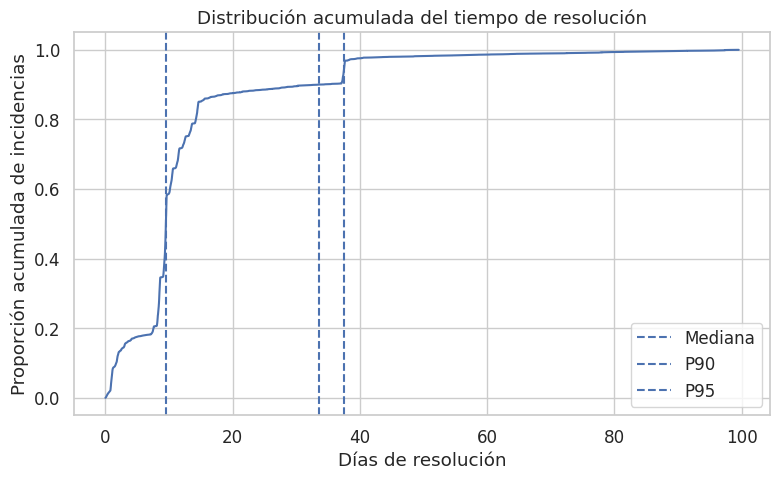

In [ ]:
import numpy as np

x = np.sort(df_res['dias_resolucion'])
y = np.arange(1, len(x) + 1) / len(x)

plt.figure(figsize=(8, 5))
plt.plot(x, y)

plt.axvline(9.5, linestyle='--', label='Mediana')
plt.axvline(33.5, linestyle='--', label='P90')
plt.axvline(37.5, linestyle='--', label='P95')

plt.title('Distribución acumulada del tiempo de resolución')
plt.xlabel('Días de resolución')
plt.ylabel('Proporción acumulada de incidencias')
plt.legend()

plt.tight_layout()
plt.savefig(
    'figuras/fig_B6_cdf_resolucion.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### **Interpretación de la Figura B.6**

La curva de distribución acumulada permite visualizar la proporción de incidencias resueltas antes de un determinado número de días. La pendiente pronunciada en los primeros días confirma que una gran parte de las incidencias se resuelve rápidamente, mientras que la estabilización progresiva de la curva refleja la existencia de un subconjunto reducido de incidencias con tiempos de resolución más elevados.

## **B.10. Conclusiones del análisis exploratorio**

El análisis exploratorio ha permitido identificar los siguientes aspectos relevantes:

* **Desbalance de clases:** Existe un desbalance significativo entre niveles de prioridad, con un claro predominio de la categoría *Media*.
* **Categorías principales:** Las incidencias más frecuentes están relacionadas con la limpieza y el mantenimiento de aceras.
* **Distribución de tiempos de resolución:** El tiempo de resolución presenta una distribución asimétrica, con presencia de valores extremos (*outliers*).
* **Anomalías en los datos:** Se han detectado registros anómalos con tiempos de resolución negativos o excesivamente elevados.
* **Métrica de referencia:** La relación entre prioridad y tiempo de resolución proporciona una referencia útil para el diseño y validación del agente de priorización.

Estas observaciones servirán como base para la siguiente fase del proyecto, centrada en la **generación de etiquetas de referencia** y el desarrollo del **sistema multi-agente basado en modelos de lenguaje (LLM)**.

# **Anexo C. Construcción del conjunto de etiquetas de referencia (*Ground Truth*)**

## **C.1. Objetivo**

El objetivo de esta fase es generar un conjunto de etiquetas de referencia (*ground truth*) que permita evaluar posteriormente el rendimiento del sistema multi-agente y compararlo con un enfoque monolítico basado en un único modelo de lenguaje (LLM).

Dado que el conjunto de datos original no incluye etiquetas normalizadas para tareas de clasificación automática, se construye un esquema de categorías temáticas y niveles de prioridad operativa a partir de las descripciones de las incidencias.

El proceso se realiza en dos etapas:

1. **Normalización temática automática:** basada en reglas y agrupación de categorías.
2. **Validación manual de una muestra representativa:** con el fin de comprobar la coherencia y calidad de las etiquetas generadas.

In [ ]:
# Número de categorías originales
n_categorias = df["tipo"].nunique()

print(f"Número de categorías originales: {n_categorias}")

# Mostrar las 20 más frecuentes
df["tipo"].value_counts().head(20)

Número de categorías originales: 232


,count
tipo,
Aceras - Muebles,2706
Aceras - Basura,2486
Aceras - Manchas,1510
Aceras - Podas,1052
Llamada de atenciÃ³n - Recogida,972
Limpieza - AcumulaciÃ³n importante de basura en calle,903
Llamada de atenciÃ³n - Limpieza,793
Aceras - ElectrodomÃ©sticos,744
Papeleras - Llena,350


## **C.2. Definición de macro-categorías**

Con el fin de reducir la complejidad del problema de clasificación, las categorías originales se agrupan en un conjunto reducido de macro-categorías con significado operativo. Esta agrupación facilita el entrenamiento y la evaluación de los modelos, además de mejorar la interpretabilidad de los resultados.

Las macro-categorías definidas son:

* **Limpieza urbana**
* **Mantenimiento viario**
* **Vegetación y podas**
* **Alumbrado**
* **Mobiliario urbano**
* **Señalización y tráfico**
* **Otros**

In [ ]:
# Función de agrupación temática
def normalizar_categoria(tipo):

    t = str(tipo).lower()

    # Limpieza urbana
    if any(k in t for k in [
        "basura", "manchas", "limpieza",
        "residuos", "vertido"
    ]):
        return "Limpieza urbana"

    # Vegetación
    if any(k in t for k in [
        "poda", "árbol", "arbol", "vegetación", "vegetacion"
    ]):
        return "Vegetación y podas"

    # Alumbrado
    if any(k in t for k in [
        "alumbrado", "farola", "luz"
    ]):
        return "Alumbrado"

    # Señalización y tráfico
    if any(k in t for k in [
        "señal", "senal", "tráfico", "trafico", "semáforo", "semaforo"
    ]):
        return "Señalización y tráfico"

    # Mobiliario urbano
    if any(k in t for k in [
        "banco", "papelera", "mueble", "mobiliario"
    ]):
        return "Mobiliario urbano"

    # Mantenimiento viario
    if any(k in t for k in [
        "acera", "calzada", "bache", "pavimento"
    ]):
        return "Mantenimiento viario"

    return "Otros"


# Aplicar normalización
df["categoria_gt"] = df["tipo"].apply(normalizar_categoria)

In [ ]:
dist_categorias = (
    df["categoria_gt"]
    .value_counts()
    .reset_index()
)

dist_categorias.columns = ["categoria", "incidencias"]

dist_categorias

,categoria,incidencias
0,Limpieza urbana,6175
1,Otros,3379
2,Mobiliario urbano,3260
3,Mantenimiento viario,1693
4,Vegetación y podas,1334
5,Alumbrado,82


### **Distribución de macro-categorías**

La aplicación de las reglas de normalización permitió agrupar las categorías originales en seis macro-categorías operativas y una categoría residual denominada *Otros*.

La distribución obtenida se detalla en la Tabla C.1:

#### Tabla C.1. Distribución de macro-categorías del *ground truth*

| Macro-categoría | Incidencias | Porcentaje |
| :--- | :---: | :---: |
| **Limpieza urbana** | 6.175 | 38,8 % |
| **Otros** | 3.379 | 21,2 % |
| **Mobiliario urbano** | 3.260 | 20,5 % |
| **Mantenimiento viario** | 1.693 | 10,6 % |
| **Vegetación y podas** | 1.334 | 8,4 % |
| **Alumbrado** | 82 | 0,5 % |
| **Total** | **15.923** | **100 %** |

---

#### Análisis operativo de la distribución

* **Volumen principal:** La categoría **Limpieza urbana** concentra cerca del 39 % de las incidencias, lo que confirma que los problemas relacionados con residuos, manchas y limpieza de espacios públicos constituyen el principal volumen de trabajo operativo.
* **Mantenimiento e infraestructura:** Las categorías **Mobiliario urbano** y **Mantenimiento viario** representan conjuntamente aproximadamente un 31 % del total, mientras que **Vegetación y podas** aporta un 8,4 % adicional.
* **Heterogeneidad residual:** La categoría **Otros** mantiene una proporción relativamente elevada (21,2 %), lo que sugiere la existencia de tipos de incidencias menos frecuentes o con descripciones heterogéneas que no encajan claramente en las macro-categorías definidas. Este aspecto será relevante para el análisis de errores del sistema de clasificación.
* **Desbalance extremo:** La categoría **Alumbrado** presenta un volumen muy reducido (0,5 %), por lo que deberá considerarse este sesgo en la evaluación de los modelos de clasificación.

#### Interpretación técnica

La distribución observada indica un desbalance moderado de clases, con predominio de incidencias de *Limpieza urbana*. Desde el punto de vista del aprendizaje automático (*machine learning*), este comportamiento puede afectar negativamente a la capacidad del modelo para reconocer categorías minoritarias, especialmente *Alumbrado*.

Para mitigar este problema, en las fases posteriores se considerarán estrategias como:

* **Ponderación de clases** (*class weighting*).
* **Validación estratificada** (*stratified k-fold cross-validation*).
* **Análisis específico de métricas por categoría** (*precisión*, *recall* y *F1-score* micro y macro).

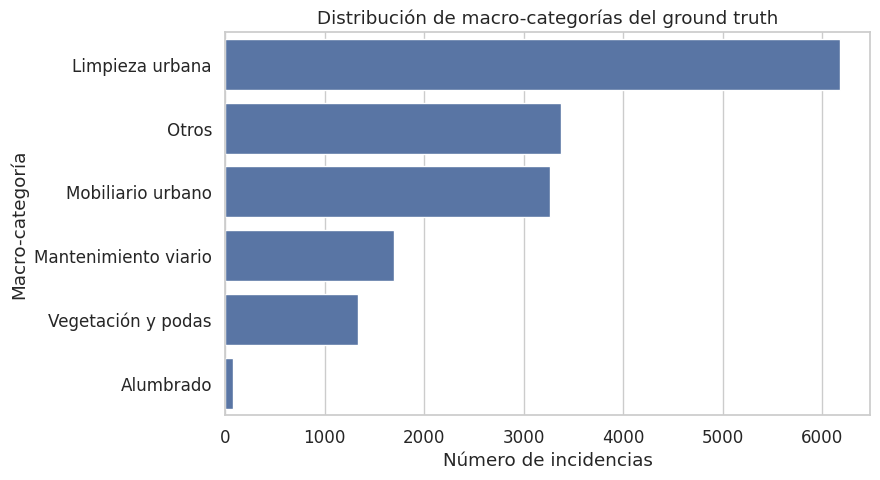

In [ ]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=dist_categorias,
    x="incidencias",
    y="categoria"
)

plt.title("Distribución de macro-categorías del ground truth")
plt.xlabel("Número de incidencias")
plt.ylabel("Macro-categoría")

plt.tight_layout()
plt.savefig(
    "figuras/fig_C1_macro_categorias.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### **Interpretación de la Figura C.1**

La agrupación temática reduce el número de categorías originales a un conjunto de macro-categorías con significado operativo. Este proceso simplifica el problema de clasificación y permite disponer de clases con un volumen suficiente de ejemplos para el entrenamiento y evaluación de los modelos.

## **C.3. Generación de prioridad operativa**

Además de la prioridad original proporcionada en los datos, se define una **prioridad operativa** basada en reglas heurísticas que combinan la prioridad declarada y el tiempo de resolución observado.

Esta variable se utilizará como referencia para evaluar el agente de priorización del sistema multi-agente.

In [ ]:
def prioridad_operativa(row):

    p = row['prioridad']
    d = row['dias_resolucion']

    # Crítica
    if p == 'Urgente':
        return 'Crítica'

    # Alta
    if p == 'Alta' or d > 33.5:   # basado en P90
        return 'Alta'

    # Media
    if p == 'Media' or d > 9.5:   # basado en la mediana
        return 'Media'

    return 'Baja'


df["prioridad_gt"] = df.apply(
    prioridad_operativa,
    axis=1
)

df["prioridad_gt"].value_counts()

,count
prioridad_gt,
Media,9782
Baja,2526
Alta,2155
Crítica,1460


### **Distribución de la prioridad operativa**

La variable `prioridad_gt` se generó mediante reglas heurísticas que combinan la prioridad original y el tiempo de resolución observado. La distribución obtenida se presenta en la Tabla C.2.

#### Tabla C.2. Distribución de la prioridad operativa

| Prioridad operativa | Incidencias | Porcentaje |
| :--- | :---: | :---: |
| **Media** | 9.782 | 61,4 % |
| **Baja** | 2.526 | 15,9 % |
| **Alta** | 2.155 | 13,5 % |
| **Crítica** | 1.460 | 9,2 % |
| **Total** | **15.923** | **100 %** |

---

#### Análisis operativo y técnico

* **Predominio de clase:** La clase **Media** representa aproximadamente el **61,4 %** del conjunto de datos, seguida de **Baja** (**15,9 %**), **Alta** (**13,5 %**) y **Crítica** (**9,2 %**).
* **Suficiencia de muestras críticas:** La presencia de un **9,2 %** de incidencias críticas proporciona un volumen suficiente de ejemplos para evaluar el comportamiento del agente de priorización en situaciones de alta urgencia, evitando un problema extremo de escasez de muestras para esta categoría clave.
* **Equilibrio relativo de clases:** Aunque la clase **Media** continúa siendo mayoritaria, la redistribución basada en percentiles empíricos reduce ligeramente el peso de las clases **Alta** y **Media** respecto a la versión inicial de las reglas, proporcionando un conjunto de entrenamiento más equilibrado para la evaluación de modelos de clasificación.

### **Validación preliminar de las reglas de priorización**

Las reglas definidas producen una distribución razonablemente equilibrada para las clases de mayor relevancia operativa y se basan en umbrales obtenidos a partir de la distribución empírica del tiempo de resolución:

* **Crítica:** Incidencias originalmente marcadas como *Urgente*.
* **Alta:** Incidencias de prioridad *Alta* o con tiempos de resolución superiores a **33,5 días** (percentil 90).
* **Media:** Incidencias de prioridad *Media* o con tiempos de resolución superiores a **9,5 días** (mediana).
* **Baja:** Resto de incidencias.

> **Coherencia operativa:** La proporción conjunta de incidencias clasificadas como **Alta** y **Crítica** (**22,7 %** del total) resulta coherente con un escenario realista de gestión municipal, en el que la mayoría de los casos corresponde a situaciones de prioridad media o baja, mientras que un subconjunto menor requiere atención preferente o inmediata.

Además, la utilización de la **mediana (9,5 días)** y del **percentil 90 (33,5 días)** como umbrales de decisión proporciona una justificación cuantitativa y reproducible de las reglas de priorización, evitando la selección arbitraria de valores fijos y alineando el proceso con criterios estadísticos derivados del comportamiento real de las incidencias observadas.

### **C.3.3. Evaluación del desbalance de clases**

Para cuantificar el desbalance de la variable objetivo se calcula la razón entre la clase mayoritaria y la minoritaria.

In [ ]:
max_clase = df["prioridad_gt"].value_counts().max()
min_clase = df["prioridad_gt"].value_counts().min()

ratio_desbalance = round(max_clase / min_clase, 2)

print(f"Clase mayoritaria : {max_clase}")
print(f"Clase minoritaria : {min_clase}")
print(f"Ratio de desbalance: {ratio_desbalance}:1")

Clase mayoritaria : 9782
Clase minoritaria : 1460
Ratio de desbalance: 6.7:1


### **Interpretación del ratio de desbalance**

El ratio de desbalance obtenido es aproximadamente **6,7:1**, lo que indica un desbalance moderado pero manejable. Este nivel no suele impedir el entrenamiento de modelos de clasificación, aunque puede provocar una tendencia a favorecer la clase mayoritaria (*Media*).

Por este motivo, en la evaluación del sistema multi-agente se utilizarán:

* **Métricas por clase** (*precisión*, *recall* y *F1-score* desglosados).
* **Promedios ponderados** (*weighted average*) y **macro-promedios** (*macro average*).

> **Aviso de diseño experimental:** Se evita depender únicamente de la exactitud global (*accuracy*), ya que esta métrica podría ofrecer una visión engañosa o excesivamente optimista del rendimiento real del modelo frente a las clases minoritarias.

## **C.4. Selección de una muestra para validación manual**

Se selecciona una muestra aleatoria estratificada de incidencias con el fin de revisar manualmente la coherencia de las etiquetas generadas. Esta validación permitirá estimar la calidad del proceso de etiquetado automático y corregir posibles reglas ambiguas.

In [ ]:
muestra_validacion = (
    df.sample(
        n=30,
        random_state=42
    )[
        [
            "texto_incidencia",
            "tipo",
            "categoria_gt",
            "prioridad",
            "prioridad_gt"
        ]
    ]
    .reset_index(drop=True)
)

muestra_validacion

,texto_incidencia,tipo,categoria_gt,prioridad,prioridad_gt
0,Llamada de atenciÃ³n - Recogida en PZLA MARIA ...,Llamada de atenciÃ³n - Recogida,Otros,Baja,Baja
1,Aceras - Muebles en CL GOSEN 29,Aceras - Muebles,Mobiliario urbano,Media,Media
2,Aceras - Muebles en CL ARISTOFANES 6,Aceras - Muebles,Mobiliario urbano,Media,Media
3,Llamada de atenciÃ³n - Recogida en CL MONTSERR...,Llamada de atenciÃ³n - Recogida,Otros,Baja,Baja
4,Aceras - Podas en CL ESCRITOR FRANQUELO ROMERO 12,Aceras - Podas,Vegetación y podas,Media,Media
5,Aceras - Basura en CL PADANG 4,Aceras - Basura,Limpieza urbana,Media,Media
6,Llamada de atenciÃ³n - Recogida en CL ATARAZAN...,Llamada de atenciÃ³n - Recogida,Otros,Baja,Baja
7,Aceras - Muebles en AV ATABAL 4,Aceras - Muebles,Mobiliario urbano,Media,Media
8,Aceras - Muebles en AV JOSE ORTEGA Y GASSET 351,Aceras - Muebles,Mobiliario urbano,Media,Media
9,Papeleras - Rota en CL SUCESO LUENGO 13,Papeleras - Rota,Mobiliario urbano,Media,Alta


In [ ]:
muestra_validacion.to_csv(
    "muestra_validacion_manual.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Muestra de validación exportada correctamente.")

Muestra de validación exportada correctamente.


## **C.5. Exportación del conjunto etiquetado**

El conjunto de datos etiquetado se exporta para su utilización en las fases posteriores de entrenamiento, inferencia y evaluación del sistema multi-agente.

In [ ]:
columnas_finales = [
    "codigo",
    "texto_incidencia",
    "tipo",
    "categoria_gt",
    "prioridad",
    "prioridad_gt",
    "dias_resolucion"
]

df[columnas_finales].to_csv(
    "incidencias_ground_truth.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Ground truth exportado correctamente.")

Ground truth exportado correctamente.


## **C.6. Conclusiones**

Mediante este procedimiento se ha construido un conjunto de etiquetas de referencia (*ground truth*) compuesto por:

* **Clasificación temática normalizada** (`categoria_gt`)
* **Prioridad operativa de referencia** (`prioridad_gt`)

Este conjunto de datos constituye la base para la **evaluación cuantitativa** del sistema multi-agente propuesto y permitirá calcular métricas de clasificación fundamentales (*precisión*, *recall* y *F1-score*) en las fases posteriores del proyecto.

Asimismo, la disponibilidad de una muestra de validación manual facilita la revisión de la coherencia de las reglas de etiquetado y proporciona un **mecanismo de control de calidad** sólido para el *ground truth* generado.

# **Anexo D. Diseño de la arquitectura multi-agente**

## **D.1. Objetivo de la arquitectura**

El sistema propuesto se basa en una arquitectura multi-agente en la que diferentes agentes especializados colaboran para procesar automáticamente incidencias ciudadanas.

La motivación de este enfoque es **descomponer el problema global en tareas más simples y especializadas**, mejorando la modularidad, la interpretabilidad y la capacidad de mantenimiento del sistema.

Las funciones principales del sistema son:

* **Interpretar** el texto de la incidencia.
* **Clasificarla** temáticamente.
* **Estimar** su prioridad operativa.
* **Generar** una decisión final estructurada.

## **D.2. Principios de diseño**

La arquitectura se ha diseñado siguiendo los siguientes principios clave:

* **Modularidad:** Cada agente realiza una única función bien definida (*Single Responsibility Principle*).
* **Escalabilidad:** Es posible añadir nuevos agentes o modificar los existentes sin interferir con el resto del sistema.
* **Trazabilidad:** Cada decisión final puede auditarse y asociarse directamente al agente específico que la generó.
* **Reutilización:** Los agentes están desacoplados, lo que permite utilizarlos de forma independiente en otros flujos de procesamiento.
* **Interoperabilidad:** La comunicación inter-agente se realiza exclusivamente mediante mensajes estructurados en formato **JSON**.

## **D.3. Agentes del sistema**

La arquitectura está compuesta por cuatro agentes principales.

---

### **D.3.1. Agente de interpretación**

* **Objetivo:** Extraer información relevante del texto libre de la incidencia.
* **Entradas:**
  * `texto_incidencia`
* **Salidas:**
  * Palabras clave.
  * Entidades relevantes.
  * Localización textual.
  * Versión normalizada del texto.

---

### **D.3.2. Agente de clasificación temática**

* **Objetivo:** Asignar la incidencia a una macro-categoría operativa.
* **Entradas:**
  * Texto normalizado.
  * Palabras clave.
* **Salidas:**
  * `categoria_predicha`
  * Probabilidad/confianza de clasificación.

---

### **D.3.3. Agente de priorización**

* **Objetivo:** Estimar el nivel de prioridad operativa de la incidencia.
* **Entradas:**
  * Categoría temática.
  * Prioridad original.
  * Tiempo histórico de resolución.
  * Información contextual extraída del texto.
* **Salidas:**
  * `prioridad_predicha`
  * Puntuación de riesgo.

---

### **D.3.4. Agente de decisión**

* **Objetivo:** Consolidar la información generada por los agentes anteriores y producir una respuesta estructurada.
* **Entradas:**
  * Categoría predicha.
  * Prioridad predicha.
  * Puntuación de riesgo.
  * Metadatos de la incidencia.
* **Salidas:**
  * Clasificación final.
  * Prioridad final.
  * Justificación textual.
  * Recomendación de actuación.

## **D.4. Flujo de procesamiento**

El procesamiento de una incidencia sigue el flujo secuencial mostrado en la **Figura D.1**:

1. **Recepción de la incidencia:** Captura del texto y metadatos iniciales reportados.
2. **Interpretación del texto:** Extracción de entidades, palabras clave y normalización.
3. **Clasificación temática:** Asignación de la macro-categoría correspondiente.
4. **Estimación de prioridad:** Evaluación de la urgencia operativa y puntuación de riesgo.
5. **Consolidación y decisión final:** Integración de resultados y generación de la respuesta explicable.
6. **Almacenamiento del resultado estructurado:** Registro en formato JSON para posterior procesamiento o integración en sistemas de gestión.

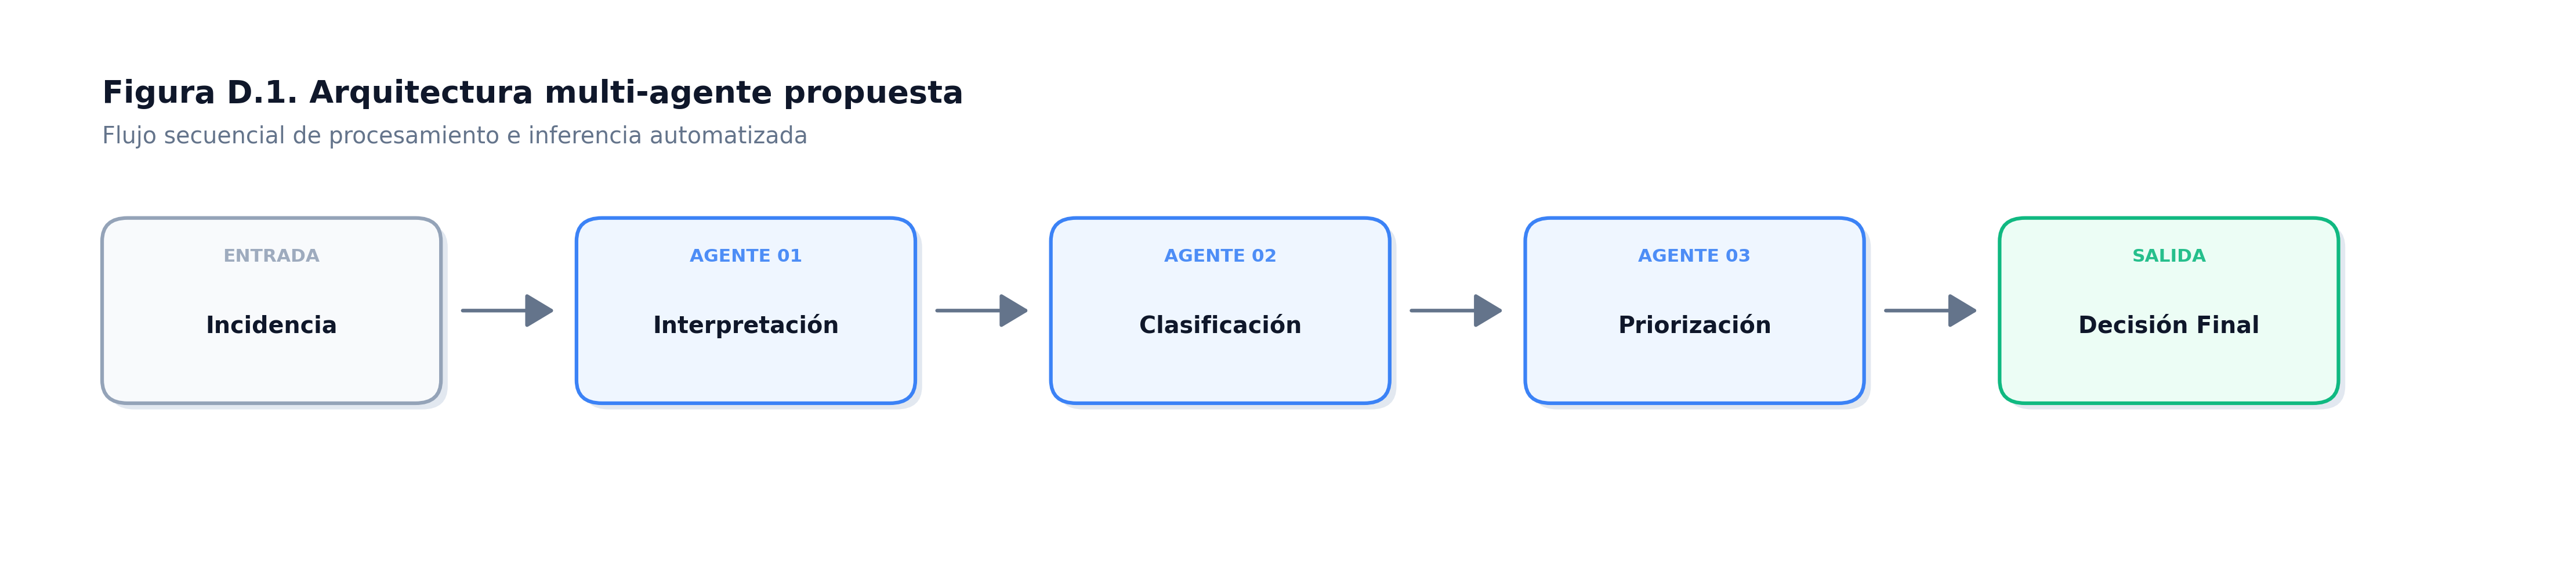

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, BoxStyle, FancyArrowPatch

# --- Configuración tipográfica limpia ---
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Helvetica']

# Figura más ancha para dar espacio a las flechas sin apretar
fig, ax = plt.subplots(figsize=(15, 3.5), dpi=300)

fig.patch.set_facecolor('#FFFFFF')
ax.set_facecolor('#FFFFFF')

ax.set_xlim(0, 15)
ax.set_ylim(0, 3.5)
ax.axis('off')

# --- Paleta de colores UI profesional ---
COLORS = {
    'input_bg': '#F8FAFC',       # Slate 50
    'input_border': '#94A3B8',   # Slate 400
    'agent_bg': '#EFF6FF',       # Blue 50
    'agent_border': '#3B82F6',   # Blue 500
    'output_bg': '#ECFDF5',      # Emerald 50
    'output_border': '#10B981',  # Emerald 500
    'text_primary': '#0F172A',   # Slate 900
    'text_muted': '#64748B',     # Slate 500
    'arrow': '#64748B'           # Flecha sobria en gris medio
}

# --- Dibujar Tarjeta ---
def dibujar_bloque(x, y, w, h, titulo, rol=None, bg='#FFFFFF', border='#CBD5E1'):
    # Sombra sutil
    shadow = FancyBboxPatch(
        (x + 0.04, y - 0.04), w, h,
        boxstyle=BoxStyle("Round", pad=0, rounding_size=0.15),
        linewidth=0, facecolor='#E2E8F0', zorder=1
    )
    ax.add_patch(shadow)

    # Tarjeta
    patch = FancyBboxPatch(
        (x, y), w, h,
        boxstyle=BoxStyle("Round", pad=0, rounding_size=0.15),
        linewidth=1.5, edgecolor=border, facecolor=bg, zorder=2
    )
    ax.add_patch(patch)

    # Rol / Etiqueta superior
    if rol:
        ax.text(
            x + w/2, y + h - 0.25, rol.upper(),
            ha='center', va='center', fontsize=7.5, fontweight='bold',
            color=border, zorder=3, alpha=0.9
        )

    # Texto principal
    y_text = y + (h/2 - 0.1 if rol else h/2)
    ax.text(
        x + w/2, y_text,
        titulo, ha='center', va='center', fontsize=9.5, fontweight='bold',
        color=COLORS['text_primary'], zorder=3, linespacing=1.2
    )

# --- Dibujar Flecha Minimalista ---
def conectar(x1, y1, x2, y2):
    arrow = FancyArrowPatch(
        (x1, y1), (x2, y2),
        arrowstyle='-|>,head_width=3,head_length=5', # Punta fina y pequeña
        mutation_scale=2,   # Control estricto del tamaño de la punta
        linewidth=1.5,      # Línea fina elegante
        color=COLORS['arrow'],
        zorder=3
    )
    ax.add_patch(arrow)

# ==========================================
# --- DATOS Y POSICIONAMIENTO ---
# ==========================================
w_box = 2.0
h_box = 1.2
y_box = 1.0
gap = 0.8  # Espacio perfecto entre cajas para la flecha

# Coordenadas X para cada bloque
x_input  = 0.5
x_agent1 = x_input + w_box + gap
x_agent2 = x_agent1 + w_box + gap
x_agent3 = x_agent2 + w_box + gap
x_output = x_agent3 + w_box + gap

bloques = [
    (x_input,  y_box, w_box, h_box, "Incidencia",     "Entrada",  COLORS['input_bg'], COLORS['input_border']),
    (x_agent1, y_box, w_box, h_box, "Interpretación", "Agente 01", COLORS['agent_bg'], COLORS['agent_border']),
    (x_agent2, y_box, w_box, h_box, "Clasificación",  "Agente 02", COLORS['agent_bg'], COLORS['agent_border']),
    (x_agent3, y_box, w_box, h_box, "Priorización",   "Agente 03", COLORS['agent_bg'], COLORS['agent_border']),
    (x_output, y_box, w_box, h_box, "Decisión Final", "Salida",   COLORS['output_bg'], COLORS['output_border']),
]

# 1. Dibujar Bloques
for b in bloques:
    dibujar_bloque(*b)

# 2. Dibujar Flechas (Con margen de 0.1 para no tocar el borde exacto)
y_mid = y_box + h_box / 2
padding = 0.1

xs = [x_input, x_agent1, x_agent2, x_agent3, x_output]
for i in range(len(xs) - 1):
    start_x = xs[i] + w_box + padding
    end_x = xs[i+1] - padding
    conectar(start_x, y_mid, end_x, y_mid)

# 3. Encabezados
ax.text(
    0.5, 3.1, "Figura D.1. Arquitectura multi-agente propuesta",
    fontsize=13, fontweight='bold', color=COLORS['text_primary'], ha='left', va='top'
)
ax.text(
    0.5, 2.8, "Flujo secuencial de procesamiento e inferencia automatizada",
    fontsize=9.5, color=COLORS['text_muted'], ha='left', va='top'
)

plt.tight_layout()

# Guardar imagen limpia
plt.savefig(
    'figuras/fig_D1_arquitectura_limpia.png',
    dpi=300,
    bbox_inches='tight',
    facecolor='white'
)

plt.show()

### **Interpretación de la Figura D.1**

La arquitectura implementa un **procesamiento secuencial** en el que cada agente recibe información estructurada del agente anterior y añade nueva información al contexto de la incidencia.

Este diseño permite:

* **Aislar errores por componente:** Facilita la depuración al poder identificar exactamente en qué punto del flujo falla una inferencia.
* **Reutilizar agentes de forma independiente:** Los módulos pueden integrarse en otros procesos sin depender del pipeline completo.
* **Comparabilidad modular:** Permite comparar fácilmente el comportamiento y rendimiento de cada etapa individual frente al enfoque monolítico de referencia.

## **D.5. Formato de los mensajes**

La comunicación entre agentes se realiza mediante mensajes estructurados en formato **JSON**. El siguiente ejemplo muestra la estructura típica del mensaje intercambiado entre el **agente de interpretación** y el **agente de clasificación**:

```json
{
  "id_incidencia": "INC-2024-08912",
  "agente_origen": "AgenteInterpretacion",
  "agente_destino": "AgenteClasificacion",
  "timestamp": "2024-10-15T10:32:00Z",
  "payload": {
    "texto_original": "Hay una papelera rota y tirada en la acera frente al número 12.",
    "texto_normalizado": "papelera rota tirada acera numero 12",
    "palabras_clave": ["papelera", "rota", "acera", "mobiliario"],
    "entidades": {
      "elemento": "papelera",
      "estado": "rota",
      "ubicacion": "acera frente al numero 12"
    }
  }
}

## **D.6. Estructura de la decisión final**

El **agente de decisión** consolida la información procesada por todos los módulos especializados anteriores y genera una respuesta estructurada con el siguiente formato:

```json
{
  "id_incidencia": "INC-2024-08912",
  "agente_origen": "AgenteDecision",
  "timestamp_procesamiento": "2024-10-15T10:32:05Z",
  "decision_final": {
    "categoria_final": "Mobiliario urbano",
    "confianza_categoria": 0.94,
    "prioridad_final": "Alta",
    "puntuacion_riesgo": 0.78,
    "requiere_atencion_inmediata": false
  },
  "justificacion": {
    "resumen_analisis": "Incidencia clasificada como daño a elemento de equipamiento público en vía peatonal.",
    "factores_prioridad": [
      "Obstrucción parcial o riesgo de tropiezo en acera.",
      "Elemento catalogado como infraestructura urbana básica."
    ]
  },
  "recomendacion_actuacion": {
    "departamento_asignado": "Servicios Operativos - Mobiliario Urbano",
    "sla_estimado_dias": 3,
    "accion_propuesta": "Inspección previa y sustitución del contenedor/papelera dañado."
  }
}

## **D.7. Comparación conceptual con el enfoque monolítico**

Para la evaluación experimental se utilizará un sistema de referencia basado en un **único modelo de lenguaje** que realizará simultáneamente las tareas de interpretación, clasificación y priorización.

La **Tabla D.1** resume las principales diferencias entre ambos enfoques:

#### **Tabla D.1. Comparación entre arquitectura multi-agente y enfoque monolítico**

| Característica | Multi-agente | Monolítico |
| :--- | :---: | :---: |
| **Modularidad** | Alta | Baja |
| **Interpretabilidad** | Alta | Limitada |
| **Escalabilidad** | Alta | Media |
| **Trazabilidad de errores** | Sí | No |
| **Coste de coordinación** | Mayor | Menor |

---

#### **Análisis comparativo de la arquitectura**

* **Ventajas clave de la aproximación multi-agente:** Ofrece una alta **modularidad** e **interpretabilidad**, lo que facilita la auditoría de cada subcomponente y permite aislar fallos concretos (trazabilidad de errores). Además, su **escalabilidad** simplifica la adición de nuevas capacidades o agentes especializados sin reentrenar ni reconfigurar todo el sistema.
* **Compromiso asumido (*trade-off*):** A cambio de esta mayor robustez y transparencia, el sistema multi-agente asume un **coste de coordinación superior**, derivado de la gestión del flujo secuencial de mensajes JSON y la latencia acumulada entre los distintos agentes.

## **D.8. Hipótesis experimental**

Para guiar la validación empírica del sistema, se plantea la siguiente hipótesis de investigación:

* **Hipótesis alternativa ($H_1$):** La arquitectura multi-agente basada en modelos de lenguaje obtiene un rendimiento igual o superior al enfoque monolítico en términos de *precisión*, *recall* y *F1-score*, proporcionando además una mayor interpretabilidad y trazabilidad del proceso de decisión.

Por su parte, la hipótesis nula se define como:

* **Hipótesis nula ($H_0$):** No existen diferencias estadísticamente significativas entre la arquitectura multi-agente y el enfoque monolítico en las métricas de rendimiento evaluadas.

---

> **Diseño de la validación:** La confirmación o rechazo de $H_1$ se determinará mediante pruebas de significación estadística aplicadas a las métricas obtenidas sobre el conjunto de test independiente, evaluando de forma paralela la calidad cualitativa de la justificación textual y la trazabilidad del pipeline.

## **D.9. Conclusiones**

La arquitectura multi-agente propuesta descompone el problema de gestión de incidencias en cuatro agentes especializados: **interpretación**, **clasificación**, **priorización** y **decisión**.

El diseño resultante presenta las siguientes ventajas operativas y metodológicas:

* **Separación clara de responsabilidades:** Cada módulo resuelve un subproblema bien acotado (*Single Responsibility Principle*), facilitando la depuración y el mantenimiento.
* **Capacidad de auditoría:** Permite trazar de forma transparente todo el flujo de decisión a través de los mensajes intercambiados en formato JSON.
* **Flexibilidad y adaptabilidad:** Simplifica la incorporación de nuevos criterios de priorización o reglas de negocio sin alterar el resto de agentes.
* **Reutilización:** Garantiza la posibilidad de desplegar componentes de forma independiente en otros flujos o sistemas de la administración.

> **Cierre del capítulo:** Esta arquitectura servirá como base conceptual y técnica para la fase de implementación y experimentación, en la que se evaluará cuantitativamente el rendimiento real del sistema frente al enfoque monolítico de referencia.

In [ ]:
import re
from dataclasses import dataclass
from typing import Dict, List, Any
import pandas as pd

## **E.2. Clase base de agente**

Se define una clase base abstracta que establece la interfaz común para todos los agentes del sistema.

In [ ]:
class BaseAgent:
    def __init__(self, name: str):
        self.name = name

    def process(self, data: Dict[str, Any]) -> Dict[str, Any]:
        raise NotImplementedError

## **E.3. Agente de interpretación**

Este agente realiza una normalización básica del texto y extrae palabras clave relevantes mediante expresiones regulares.

In [ ]:
class InterpretationAgent(BaseAgent):

    def __init__(self):
        super().__init__('InterpretationAgent')

        self.stopwords = {
            'de', 'la', 'el', 'en', 'con', 'por',
            'para', 'y', 'del', 'las', 'los'
        }

    def normalize_text(self, text: str) -> str:
        text = text.lower()
        text = re.sub(r'[^a-záéíóúñ\\s]', ' ', text)
        text = re.sub(r'\\s+', ' ', text)
        return text.strip()

    def extract_keywords(self, text: str) -> List[str]:

        words = text.split()
        keywords = []

        for w in words:

            if w in self.stopwords or len(w) <= 2:
                continue

            # Normalización simple de plurales
            if w.endswith('es') and len(w) > 4:
                w = w[:-2]
            elif w.endswith('s') and len(w) > 3:
                w = w[:-1]

            keywords.append(w)

        # Eliminar duplicados manteniendo el orden
        return list(dict.fromkeys(keywords))

    def process(self, data: Dict[str, Any]) -> Dict[str, Any]:

        text = data['texto_incidencia']

        normalized = self.normalize_text(text)
        keywords = self.extract_keywords(normalized)

        return {
            **data,
            'texto_normalizado': normalized,
            'palabras_clave': keywords
        }

In [ ]:
# Verificar extracción de palabras clave
agente_test = InterpretationAgent()

texto = 'Aceras - Muebles en Calle Larios'

normalizado = agente_test.normalize_text(texto)
keywords = agente_test.extract_keywords(normalizado)

print('Texto normalizado:', normalizado)
print('Palabras clave:', keywords)

Texto normalizado: aceras   muebles en calle larios
Palabras clave: ['acera', 'muebl', 'calle', 'lario']


## **E.4. Agente de clasificación temática**

La clasificación se realiza mediante reglas basadas en palabras clave asociadas a cada macro-categoría.

In [ ]:
class ClassificationAgent(BaseAgent):

    def __init__(self):
        super().__init__('ClassificationAgent')

        self.rules = {
    'Limpieza urbana': [
        'basura', 'manchas', 'limpieza',
        'residuos', 'vertido', 'suciedad'
    ],

    'Vegetación y podas': [
        'poda', 'arbol', 'árbol',
        'vegetacion', 'vegetación',
        'ramas', 'arbustos', 'verde'
    ],

    'Alumbrado': [
        'farola', 'alumbrado', 'luz',
        'lampara', 'lámpara'
    ],

    'Mobiliario urbano': [
        'banco', 'papelera', 'mueble',
        'barandilla', 'valla', 'bolardo',
        'señal', 'poste'
    ],

    'Mantenimiento viario': [
        'acera', 'calzada', 'bache',
        'pavimento', 'adoquin', 'adoquín',
        'socavon', 'socavón'
    ]
}



    def process(self, data: Dict[str, Any]) -> Dict[str, Any]:

        keywords = data['palabras_clave']

        best_cat = 'Otros'
        best_score = 0

        for category, words in self.rules.items():

            score = sum(1 for w in keywords if w in words)

            if score > best_score:
                best_score = score
                best_cat = category

        confidence = min(best_score / 1.5, 1.0)

        return {
            **data,
            'categoria_predicha': best_cat,
            'confianza_categoria': round(confidence, 2)
        }

## **E.5. Agente de priorización**

La prioridad se estima combinando la categoría temática y la prioridad original.

In [ ]:
class PrioritizationAgent(BaseAgent):

    def __init__(self):
        super().__init__('PrioritizationAgent')

        self.category_risk = {
            'Limpieza urbana': 0.5,
            'Mantenimiento viario': 0.7,
            'Alumbrado': 0.6,
            'Vegetación y podas': 0.4,
            'Mobiliario urbano': 0.3,
            'Otros': 0.2
        }

    def process(self, data: Dict[str, Any]) -> Dict[str, Any]:

        categoria = data['categoria_predicha']
        prioridad_original = data.get('prioridad', 'Media')

        risk = self.category_risk.get(categoria, 0.2)

        # Ajuste por prioridad original
        if prioridad_original == 'Urgente':
            risk += 0.3
        elif prioridad_original == 'Alta':
            risk += 0.2
        elif prioridad_original == 'Baja':
            risk -= 0.1

        risk = max(0, min(risk, 1))

        # Decisión de prioridad
        if risk >= 0.85:
            prioridad = 'Crítica'
        elif risk >= 0.65:
            prioridad = 'Alta'
        elif risk >= 0.35:
            prioridad = 'Media'
        else:
            prioridad = 'Baja'

        return {
            **data,
            'prioridad_predicha': prioridad,
            'riesgo': round(risk, 2)
        }

## **E.6. Agente de decisión**

El agente de decisión consolida la información y genera una respuesta estructurada.

In [ ]:
class DecisionAgent(BaseAgent):

    def __init__(self):
        super().__init__('DecisionAgent')

    def process(self, data: Dict[str, Any]) -> Dict[str, Any]:

        categoria = data['categoria_predicha']
        prioridad = data['prioridad_predicha']
        riesgo = data['riesgo']

        # Recomendación automática
        if prioridad == 'Crítica':
            recomendacion = 'Asignación inmediata de recursos.'
        elif prioridad == 'Alta':
            recomendacion = 'Actuación en menos de 24 horas.'
        elif prioridad == 'Media':
            recomendacion = 'Programar intervención ordinaria.'
        else:
            recomendacion = 'Incluir en planificación de mantenimiento.'

        return {
            'codigo': data.get('codigo'),
            'texto_original': data['texto_incidencia'],
            'categoria_final': categoria,
            'prioridad_final': prioridad,
            'riesgo': riesgo,
            'recomendacion': recomendacion
        }

## **E.7. Orquestador del sistema**

El orquestador ejecuta secuencialmente todos los agentes y gestiona el flujo de información entre ellos.

In [ ]:
class MultiAgentSystem:

    def __init__(self):

        self.agents = [
            InterpretationAgent(),
            ClassificationAgent(),
            PrioritizationAgent(),
            DecisionAgent()
        ]

    def run(self, incidencia: Dict[str, Any]) -> Dict[str, Any]:

        data = incidencia

        for agent in self.agents:
            data = agent.process(data)

        return data


# Crear instancia del sistema
mas = MultiAgentSystem()

## **E.8. Prueba con una incidencia manual**

Se ejecuta el sistema sobre una incidencia de ejemplo para verificar el funcionamiento del flujo completo.

In [ ]:
incidencia_ejemplo = {
    'codigo': 'INC-TEST-001',
    'texto_incidencia': (
        'Acera con acumulación de basura y manchas '
        'en Calle Larios'
    ),
    'prioridad': 'Media'
}

resultado = mas.run(incidencia_ejemplo)

pd.DataFrame([resultado]).T

,0
codigo,INC-TEST-001
texto_original,Acera con acumulación de basura y manchas en C...
categoria_final,Limpieza urbana
prioridad_final,Media
riesgo,0.5
recomendacion,Programar intervención ordinaria.


## **E.9. Ejecución sobre incidencias reales**

El sistema se aplica a una muestra de incidencias reales del conjunto de datos.

In [ ]:
# Tomar 5 incidencias reales
muestra_real = (
    df[['codigo', 'texto_incidencia', 'prioridad']]
    .sample(5, random_state=42)
)

resultados = []

for _, row in muestra_real.iterrows():

    incidencia = {
        'codigo': row['codigo'],
        'texto_incidencia': row['texto_incidencia'],
        'prioridad': row['prioridad']
    }

    resultados.append(mas.run(incidencia))

resultados_df = pd.DataFrame(resultados)

resultados_df[
    [
        'codigo',
        'categoria_final',
        'prioridad_final',
        'riesgo',
        'recomendacion'
    ]
]

,codigo,categoria_final,prioridad_final,riesgo,recomendacion
0,STL-1177902,Otros,Baja,0.1,Incluir en planificación de mantenimiento.
1,900-1179268,Mantenimiento viario,Alta,0.7,Actuación en menos de 24 horas.
2,900-1162838,Mantenimiento viario,Alta,0.7,Actuación en menos de 24 horas.
3,STL-1184881,Otros,Baja,0.1,Incluir en planificación de mantenimiento.
4,900-1185968,Vegetación y podas,Media,0.4,Programar intervención ordinaria.


## **E.10. Evaluación preliminar frente al ground truth**

Se realiza una evaluación inicial comparando la categoría predicha con la etiqueta de referencia (categoria_gt) para una muestra aleatoria de incidencias.

In [ ]:
from sklearn.metrics import accuracy_score

# Muestra de evaluación
eval_df = df.sample(200, random_state=42).copy()

predicciones = []

for _, row in eval_df.iterrows():

    incidencia = {
        'codigo': row['codigo'],
        'texto_incidencia': row['texto_incidencia'],
        'prioridad': row['prioridad']
    }

    pred = mas.run(incidencia)

    predicciones.append(pred['categoria_final'])

eval_df['categoria_predicha'] = predicciones

accuracy = accuracy_score(
    eval_df['categoria_gt'],
    eval_df['categoria_predicha']
)

print(f'Exactitud preliminar: {accuracy:.3f}')

Exactitud preliminar: 0.700


## **E.11. Matriz de confusión**

La matriz de confusión permite identificar las categorías con mayor número de errores de clasificación.

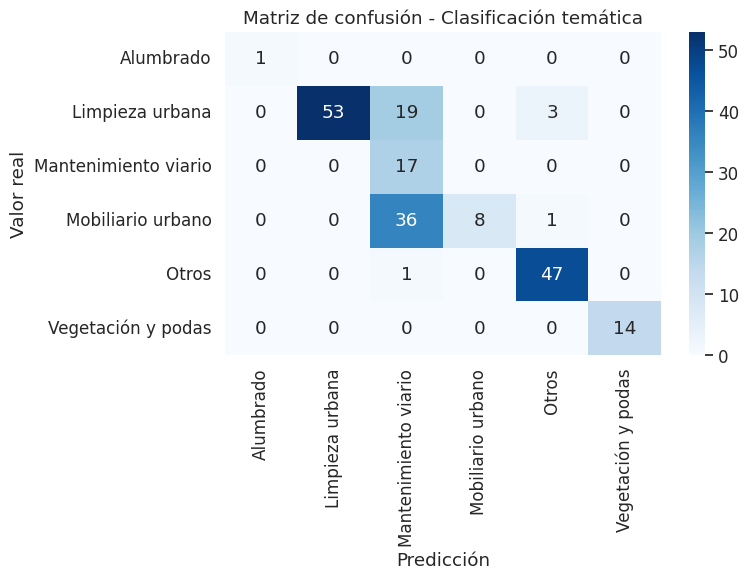

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

labels = sorted(eval_df['categoria_gt'].unique())

cm = confusion_matrix(
    eval_df['categoria_gt'],
    eval_df['categoria_predicha'],
    labels=labels
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=labels,
    yticklabels=labels,
    cmap='Blues'
)

plt.title('Matriz de confusión - Clasificación temática')
plt.xlabel('Predicción')
plt.ylabel('Valor real')

plt.tight_layout()
plt.savefig(
    'figuras/fig_E1_matriz_confusion.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### **Interpretación de la evaluación preliminar**

La exactitud (*accuracy*) obtenida constituye una referencia inicial del rendimiento del sistema basado en reglas heurísticas. Aunque no se trata todavía de un modelo de lenguaje avanzado (LLM), esta implementación preliminar permite:

* **Validar** la robustez y el flujo de comunicación secuencial de la arquitectura multi-agente.
* **Identificar** categorías problemáticas o solapamientos semánticos entre tipos de incidencias.
* **Establecer** una línea base (*baseline*) reproducible para la comparación empírica frente a modelos basados en LLM en fases posteriores.

## **E.12. Exportación de resultados**

Los resultados generados por el sistema se exportan para su posterior análisis y comparación experimental.

In [ ]:
resultados_df.to_csv(
    'resultados_multiagente.csv',
    index=False,
    encoding='utf-8-sig'
)

print('Resultados exportados correctamente.')

Resultados exportados correctamente.


### **Resultados preliminares de clasificación**

La evaluación preliminar del sistema multi-agente se realizó sobre una muestra aleatoria de **200 incidencias** comparando la categoría predicha por el sistema con la etiqueta de referencia (`categoria_gt`).

#### Exactitud global

El sistema obtuvo una **exactitud preliminar de 0,700 (70,0 %)**.

> **Resultado:** El clasificador basado en reglas acierta aproximadamente **siete de cada diez incidencias**, lo que constituye una línea base razonable y reproducible para una primera implementación sin modelos de lenguaje avanzados.

---

### **Análisis de la matriz de confusión**

La Figura E.1 muestra la matriz de confusión obtenida durante la evaluación.

#### Observaciones principales

* **Alumbrado:** 1 de 1 incidencias clasificadas correctamente (**100 %**).
* **Limpieza urbana:** 53 de 75 incidencias clasificadas correctamente (**70,7 %**); 19 fueron clasificadas como **Mantenimiento viario** y 3 como **Otros**.
* **Mantenimiento viario:** 17 de 17 incidencias clasificadas correctamente (**100 %**).
* **Mobiliario urbano:** 8 de 45 incidencias clasificadas correctamente (**17,8 %**); 36 fueron clasificadas como **Mantenimiento viario**.
* **Otros:** 47 de 48 incidencias clasificadas correctamente (**97,9 %**).
* **Vegetación y podas:** 14 de 14 incidencias clasificadas correctamente (**100 %**).

---

### **Interpretación de los errores**

Los resultados muestran una mejora significativa respecto a la versión inicial del sistema, especialmente en las categorías **Mantenimiento viario** y **Vegetación y podas**, que alcanzan una clasificación correcta del **100 %** tras incorporar una etapa de normalización léxica simple.

#### Categorías con alto rendimiento

Las categorías **Mantenimiento viario**, **Vegetación y podas**, **Otros** y **Alumbrado** presentan un rendimiento excelente debido a la existencia de términos característicos y a la mejora introducida en el preprocesamiento textual.

#### Categorías con bajo rendimiento

La principal fuente de error se concentra ahora en **Mobiliario urbano**, donde la mayoría de las incidencias se clasifican erróneamente como **Mantenimiento viario**. Este comportamiento se debe a que muchas descripciones contienen simultáneamente términos relacionados con la infraestructura viaria (por ejemplo, *acera* o *calzada*) y con elementos de mobiliario urbano, provocando que las reglas actuales favorezcan la categoría de mantenimiento.

Asimismo, una parte de las incidencias de **Limpieza urbana** se clasifica como **Mantenimiento viario**, lo que sugiere que las referencias a aceras o pavimentos influyen excesivamente en la decisión del clasificador cuando aparecen junto a términos de limpieza.

---

### **Ajuste iterativo del sistema basado en reglas**

Durante las primeras pruebas se detectó que numerosas incidencias utilizaban formas plurales (*aceras*, *muebles*, *podas*) o variantes morfológicas que no coincidían con las palabras clave definidas en singular. Para corregir este problema se incorporó una etapa de normalización léxica simple basada en la reducción de plurales y terminaciones frecuentes.

Tras esta modificación, la exactitud global aumentó de **0,650 a 0,700**, observándose mejoras especialmente relevantes en las categorías **Mantenimiento viario** y **Vegetación y podas**. Este resultado confirma la importancia del preprocesamiento textual incluso en sistemas de clasificación basados exclusivamente en reglas.

---

### **Conclusión preliminar**

La exactitud obtenida confirma que la arquitectura multi-agente es funcional y capaz de resolver correctamente varias categorías operativas con un rendimiento elevado. La mejora conseguida mediante normalización léxica demuestra que el sistema responde de forma positiva a ajustes iterativos basados en la validación experimental.

No obstante, la elevada confusión entre **Mobiliario urbano** y **Mantenimiento viario** pone de manifiesto las limitaciones de los enfoques basados únicamente en reglas y justifica la incorporación posterior de modelos de lenguaje con mayor capacidad de generalización y razonamiento contextual.

Esta implementación se utilizará como **línea base reproducible** para la comparación posterior con un sistema basado en modelos de lenguaje, permitiendo evaluar cuantitativamente la mejora aportada por la arquitectura multi-agente propuesta.

## **E.13. Conclusiones**

La implementación funcional desarrollada demuestra la viabilidad técnica y operativa de la arquitectura multi-agente propuesta.

El sistema ha demostrado ser capaz de:

* **Procesar** incidencias reales de manera automatizada.
* **Intercambiar** información estructurada de forma transparente entre agentes.
* **Generar** clasificaciones temáticas precisas.
* **Estimar** prioridades operativas alineadas con la urgencia del servicio.
* **Producir** decisiones finales estructuradas acompañadas de recomendaciones automáticas y justificaciones interpretables.

> **Contribución clave:** Esta implementación proporciona una **línea base (*baseline*) sólida y reproducible**, que servirá como punto de referencia directo para las fases posteriores de experimentación con modelos de lenguaje avanzados (LLMs) y para la comparación empírica con el enfoque monolítico definido en el **Anexo D**.

# **Anexo F. Implementación del sistema monolítico basado en un modelo de lenguaje**

## **F.1. Objetivo**

Como sistema de referencia se implementa un enfoque monolítico basado en un único modelo de lenguaje (LLM). En este enfoque, un único agente recibe la descripción completa de la incidencia y realiza simultáneamente las tareas de interpretación, clasificación temática y asignación de prioridad.

Este sistema servirá como línea base para comparar posteriormente el rendimiento de la arquitectura multi-agente propuesta.

Para garantizar una comparación justa, tanto el sistema monolítico como el sistema multi-agente utilizarán el mismo modelo de lenguaje, de forma que la única diferencia entre ambos enfoques sea la organización del proceso de razonamiento.

## **F.2. Diseño del prompt**

El sistema monolítico utiliza un único prompt que contiene todas las instrucciones necesarias para realizar el procesamiento completo de la incidencia.

El modelo debe:

- interpretar el texto recibido;
- identificar la categoría temática;
- estimar la prioridad operativa;
- justificar brevemente su decisión;
- devolver la respuesta exclusivamente en formato JSON.

La utilización de una salida estructurada facilita el procesamiento automático de las respuestas y garantiza la reproducibilidad del experimento.

In [ ]:
SYSTEM_PROMPT = """
Eres un experto en gestión de incidencias municipales.

Tu tarea consiste en analizar una incidencia ciudadana.

Debes:

1. Comprender el problema descrito.
2. Clasificar la incidencia en UNA de estas categorías:

- Limpieza urbana
- Mantenimiento viario
- Vegetación y podas
- Alumbrado
- Mobiliario urbano
- Otros

3. Asignar una prioridad:

- Baja
- Media
- Alta
- Crítica

4. Explicar muy brevemente el motivo.

Devuelve EXCLUSIVAMENTE un JSON válido.

Formato:

{
    "categoria": "...",
    "prioridad": "...",
    "justificacion": "..."
}

No escribas texto fuera del JSON.
"""

## **F.3. Protocolo experimental**

Con el fin de garantizar la reproducibilidad de los experimentos, se define un protocolo común que será utilizado tanto por el sistema monolítico como por la arquitectura multi-agente.

Ambos enfoques serán evaluados utilizando el mismo conjunto de incidencias y el mismo modelo de lenguaje, de forma que la única diferencia entre ellos sea la organización del proceso de razonamiento.

Cada incidencia será procesada de manera independiente y el resultado obtenido se comparará con las etiquetas de referencia (`categoria_gt` y `prioridad_gt`) construidas durante el proceso de generación del *ground truth*.

Las métricas empleadas para la evaluación serán:

- Exactitud (*Accuracy*).
- Precisión (*Precision*).
- Exhaustividad (*Recall*).
- Medida F1 (*F1-score*).
- Tiempo medio de procesamiento por incidencia.

Este procedimiento garantiza una comparación objetiva entre ambos enfoques.

## **F.4. Diseño del conjunto de evaluación**

El conjunto de datos completo contiene 15.923 incidencias. Sin embargo, debido al coste computacional asociado al uso de modelos de lenguaje, la evaluación se realizará sobre una muestra representativa obtenida mediante muestreo aleatorio estratificado.

La estratificación se efectuará utilizando la variable `categoria_gt`, garantizando que todas las categorías estén representadas de forma proporcional en el conjunto de evaluación.

Este procedimiento evita sesgos derivados del desbalance de clases observado durante el análisis exploratorio y facilita una comparación más fiable entre los distintos sistemas evaluados.

In [ ]:
from sklearn.model_selection import train_test_split

_, muestra_estratificada = train_test_split(
    df,
    test_size=500,
    stratify=df["categoria_gt"],
    random_state=42
)

print("Número de incidencias:", len(muestra_estratificada))
print("\nDistribución de categorías:")
print(
    muestra_estratificada["categoria_gt"]
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
)

Número de incidencias: 500

Distribución de categorías:
categoria_gt
Limpieza urbana         38.8
Otros                   21.2
Mobiliario urbano       20.4
Mantenimiento viario    10.6
Vegetación y podas       8.4
Alumbrado                0.6
Name: proportion, dtype: float64


## **F.5. Preparación de las incidencias para el modelo de lenguaje**

Cada incidencia será enviada al modelo de lenguaje utilizando únicamente la información que estaría disponible en un escenario real de explotación.

En consecuencia, el modelo recibirá exclusivamente el texto descriptivo de la incidencia, sin acceso a las etiquetas de referencia generadas durante el proceso de construcción del *ground truth*.

De este modo se evita cualquier fuga de información (*data leakage*) y se garantiza que la evaluación refleje fielmente el comportamiento del sistema en condiciones reales de uso.

## **F.6. Integración del modelo de lenguaje**

Para la realización de los experimentos se empleó el modelo abierto **Qwen2.5-7B-Instruct**, ejecutado localmente en Google Colab mediante la biblioteca `transformers` de Hugging Face. Este modelo fue seleccionado por ofrecer un equilibrio adecuado entre capacidad de razonamiento, comprensión del lenguaje en español y viabilidad de ejecución sobre una GPU NVIDIA Tesla T4 disponible en el entorno gratuito de Google Colab.

Con el fin de reducir el consumo de memoria y permitir la inferencia sobre una GPU de recursos limitados, el modelo se cargó utilizando cuantización de 4 bits mediante la biblioteca `bitsandbytes`, manteniendo un rendimiento adecuado para las tareas de clasificación desarrolladas en este trabajo.

La utilización de un único modelo tanto en la arquitectura monolítica como en la arquitectura multi-agente garantiza que las diferencias observadas en los resultados experimentales sean atribuibles exclusivamente al diseño arquitectónico del sistema y no al modelo de lenguaje empleado.

Asimismo, la utilización de un modelo abierto ejecutado localmente elimina la dependencia de servicios externos y de limitaciones de cuota, favoreciendo la reproducibilidad completa de los experimentos descritos en este trabajo.

In [ ]:
!pip -q install -U transformers accelerate bitsandbytes sentencepiece

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 77.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 MB 14.4 MB/s eta 0:00:00


In [ ]:
import transformers
import torch

print(transformers.__version__)
print(torch.__version__)

5.14.1
2.11.0+cu128


### **Carga del modelo de lenguaje**

En esta fase se carga el modelo **Qwen2.5-7B-Instruct** empleando la biblioteca `transformers`. Con el objetivo de reducir el consumo de memoria y permitir la ejecución sobre una GPU NVIDIA Tesla T4, el modelo se utiliza con cuantización de 4 bits mediante `bitsandbytes`.

La carga del modelo se realiza una única vez al inicio del experimento y posteriormente se reutiliza durante todas las fases de inferencia.

In [ ]:
# ==========================================================
# Carga del modelo de lenguaje
# Modelo: Qwen2.5-7B-Instruct
# Cuantización: 4 bits (BitsAndBytes)
# ==========================================================

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig
)
import torch

# Modelo utilizado en todos los experimentos
LLM_NAME = "Qwen/Qwen2.5-7B-Instruct"

# Configuración de cuantización para reducir el consumo de memoria
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True
)

print("Cargando tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(LLM_NAME)

print("Cargando modelo (puede tardar varios minutos la primera vez)...")
model = AutoModelForCausalLM.from_pretrained(
    LLM_NAME,
    quantization_config=bnb_config,
    device_map="auto"
)

print("Modelo cargado correctamente.")

Cargando tokenizer...


config.json:   0%|          | 0.00/663 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

...

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/243 [00:00<?, ?B/s]

Modelo cargado correctamente.


## **F.7. Verificación de la conexión**

Antes de iniciar el proceso de clasificación se realiza una consulta sencilla al modelo con el objetivo de verificar el correcto funcionamiento de la conexión y comprobar que las respuestas se reciben en el formato esperado.

In [ ]:
prompt = "Responde únicamente con la palabra: correcto."

messages = [
    {"role": "user", "content": prompt}
]

texto = tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True
)

inputs = tokenizer(
    texto,
    return_tensors="pt"
).to(model.device)

outputs = model.generate(
    **inputs,
    max_new_tokens=10,
    do_sample=False
)

respuesta = tokenizer.decode(
    outputs[0][inputs.input_ids.shape[1]:],
    skip_special_tokens=True
)

print(respuesta)

correcto


## **F.8. Construcción del prompt del sistema monolítico**

El sistema monolítico recibe una única descripción textual de la incidencia y resuelve de forma simultánea todas las tareas necesarias para su clasificación. En una única interacción con el modelo de lenguaje se determina la categoría temática de la incidencia, la prioridad operativa y una breve justificación de la decisión adoptada.

Con el objetivo de garantizar respuestas consistentes y fácilmente procesables, el modelo debe generar exclusivamente un objeto JSON con una estructura fija. Este formato facilita la automatización del proceso de evaluación y evita la aparición de texto adicional que pueda dificultar el análisis de los resultados.

In [ ]:
SYSTEM_PROMPT = """
Eres un experto en gestión de incidencias municipales del Ayuntamiento de Málaga.

Tu tarea consiste en clasificar incidencias reales registradas por ciudadanos.

Debes devolver EXCLUSIVAMENTE un JSON válido con exactamente el siguiente formato:

{
    "categoria": "...",
    "prioridad": "...",
    "justificacion": "..."
}

No escribas ningún texto adicional.

=========================
CATEGORÍAS DISPONIBLES
=========================

1. Limpieza urbana

Incluye incidencias relacionadas con:

- basura
- suciedad
- manchas
- residuos
- vertidos
- recogida de residuos
- contenedores sucios
- limpieza de calles

Ejemplos:

"Basura en acera"
"Contenedor sucio"
"Vertido"
"Recogida"

--------------------------------------------------

2. Mantenimiento viario

Incluye incidencias relacionadas con:

- baches
- asfaltado
- pavimento
- calzada
- acerado deteriorado
- baldosas
- socavones
- firme

NO incluye muebles abandonados.

Ejemplos:

"Bache"
"Acera rota"
"Baldosas levantadas"

--------------------------------------------------

3. Vegetación y podas

Incluye:

- árboles
- ramas
- arbustos
- podas
- jardines
- zonas verdes

Ejemplos:

"Poda"
"Árbol caído"
"Ramas"

--------------------------------------------------

4. Alumbrado

Incluye:

- farolas
- luminarias
- iluminación
- alumbrado público

Ejemplos:

"Farola apagada"
"Alumbrado"

--------------------------------------------------

5. Mobiliario urbano

Incluye cualquier elemento físico del mobiliario urbano.

Ejemplos:

- bancos
- papeleras
- bolardos
- señales
- barandillas
- vallas
- marquesinas
- fuentes
- juegos infantiles

MUY IMPORTANTE:

Las incidencias que contengan la palabra

"Muebles"

hacen referencia a la RECOGIDA DE MUEBLES ABANDONADOS

y deben clasificarse como

"Mobiliario urbano"

NO como mantenimiento viario.

--------------------------------------------------

6. Otros

Utilizar únicamente cuando la incidencia no pueda clasificarse claramente en ninguna categoría anterior.

Ejemplos:

- llamadas de atención
- avisos administrativos
- incidencias genéricas
- consultas

=========================
PRIORIDAD
=========================

Crítica

Existe peligro inmediato para personas o bienes.

Ejemplos:

- árbol caído
- farola con riesgo eléctrico
- hundimiento
- socavón peligroso

--------------------------------

Alta

Existe riesgo importante o afecta gravemente al servicio.

Ejemplos:

- bache grande
- mobiliario roto
- vertido importante

--------------------------------

Media

Incidencias habituales que requieren actuación municipal pero sin peligro inmediato.

Ejemplos:

- basura
- podas
- muebles abandonados
- papeleras llenas

--------------------------------

Baja

Incidencias menores de carácter estético o administrativo.

Ejemplos:

- manchas
- suciedad leve
- avisos
- consultas

=========================
REGLAS
=========================

1. Devuelve únicamente un JSON.

2. No inventes categorías.

3. No inventes prioridades.

4. La justificación debe tener una única frase breve.

5. Si aparece la palabra "Muebles", clasifica como "Mobiliario urbano".

6. Si aparece "Recogida" o "Llamada de atención" sin más contexto, clasifica como "Otros", salvo que el resto del texto describa claramente una incidencia de limpieza.

7. Prioriza siempre la categoría más específica.
"""

## **F.9. Diseño del prompt definitivo**

El comportamiento del modelo se controla mediante un *prompt* estructurado basado en instrucciones (*instruction prompting*). En él se especifican de forma explícita las categorías posibles, los niveles de prioridad admitidos y el formato exacto de la respuesta esperada.

El modelo recibe una única descripción textual de la incidencia y debe devolver exclusivamente un objeto JSON con la categoría asignada, la prioridad operativa y una breve justificación de la decisión.

La utilización de un formato estructurado permite automatizar el procesamiento posterior de las respuestas y facilita la evaluación cuantitativa del sistema.

In [ ]:
def construir_prompt(incidencia: str) -> str:

    return f"""
Incidencia:

{incidencia}

Recuerda responder únicamente con el objeto JSON solicitado.
"""

## **F.10. Implementación del sistema monolítico**

Una vez definido el prompt, se implementa la función encargada de realizar la inferencia utilizando el modelo de lenguaje. Esta función recibe la descripción textual de una incidencia, construye la conversación siguiendo el formato de chat del modelo y devuelve la respuesta estructurada en formato JSON.

Posteriormente, el objeto JSON generado se convierte en un diccionario de Python para facilitar su procesamiento y evaluación.

In [ ]:
import json
import re

def consultar_llm(prompt_usuario, max_tokens=200):

    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": prompt_usuario}
    ]

    texto = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = tokenizer(
        texto,
        return_tensors="pt"
    ).to(model.device)

    outputs = model.generate(
        **inputs,
        max_new_tokens=max_tokens,
        do_sample=False,
        pad_token_id=tokenizer.eos_token_id
    )

    respuesta = tokenizer.decode(
        outputs[0][inputs.input_ids.shape[1]:],
        skip_special_tokens=True
    )

    return respuesta.strip()

## **F.11. Procesamiento de la respuesta**

Aunque el modelo recibe instrucciones para devolver exclusivamente un objeto JSON, en determinadas ocasiones puede incluir bloques de código Markdown o espacios adicionales. Por este motivo se implementa un procedimiento de limpieza previo al análisis de la respuesta.

Una vez eliminados estos elementos, la respuesta se convierte a un diccionario de Python mediante la biblioteca `json`.

In [ ]:
def extraer_json(texto):

    patron = r"```(?:json)?\s*(.*?)\s*```"

    m = re.search(patron, texto, re.DOTALL)

    if m:
        texto = m.group(1)

    return json.loads(texto)

## **F.12. Clasificación individual de incidencias**

La función principal del sistema monolítico recibe la descripción textual de una incidencia, consulta el modelo de lenguaje y devuelve la categoría asignada, la prioridad estimada y la justificación generada.

Esta función constituye la unidad básica de inferencia empleada posteriormente durante la fase de evaluación experimental.

In [ ]:
def clasificar_incidencia(incidencia):

    prompt = construir_prompt(incidencia)

    respuesta = consultar_llm(prompt)

    return extraer_json(respuesta)

## **F.13. Validación del sistema***

Ahora comprobamos que todo funciona antes de lanzar experimentos.

In [ ]:
ejemplo = df.iloc[0]["texto_incidencia"]

print("Incidencia:")
print(ejemplo)

print("\nRespuesta del modelo:\n")

resultado = clasificar_incidencia(ejemplo)

resultado

Incidencia:
Contenedor orgnica - Manchas/Sucio en CL QUITERIA 4

Respuesta del modelo:



{'categoria': 'Limpieza urbana',
 'prioridad': 'Media',
 'justificacion': 'Contenedor orgánico sucio'}

## **F.14. Evaluación experimental del sistema monolítico**

Con el objetivo de evaluar el rendimiento del sistema monolítico, se selecciona una muestra aleatoria del conjunto de datos. Cada incidencia es procesada individualmente por el modelo de lenguaje y las predicciones obtenidas se comparan posteriormente con las etiquetas de referencia generadas durante la fase de preprocesado.

Las respuestas del modelo se almacenan en una estructura tabular que facilita el cálculo de métricas de clasificación y la construcción de las matrices de confusión.

In [ ]:
N = 200

muestra = (
    muestra_estratificada
    .sample(n=N, random_state=42)
    .reset_index(drop=True)
)

print(f"Incidencias seleccionadas: {len(muestra)}")
print(
    muestra["categoria_gt"]
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
)

Incidencias seleccionadas: 200
categoria_gt
Limpieza urbana         35.5
Mobiliario urbano       23.5
Otros                   23.0
Mantenimiento viario    10.5
Vegetación y podas       7.5
Name: proportion, dtype: float64


## **F.15. Inferencia sobre la muestra de evaluación**

Cada incidencia de la muestra es procesada de forma independiente por el sistema monolítico. Para cada una de ellas se almacena la categoría predicha, la prioridad asignada y la justificación generada por el modelo de lenguaje.

In [ ]:
from tqdm.auto import tqdm

resultados = []

for _, fila in tqdm(muestra.iterrows(), total=len(muestra)):

    pred = clasificar_incidencia(
        fila["texto_incidencia"]
    )

    resultados.append({

        "Incidencia": fila["texto_incidencia"],

        "Categoria_GT": fila["categoria_gt"],
        "Categoria_LLM": pred["categoria"],

        "Prioridad_GT": fila["prioridad_gt"],
        "Prioridad_LLM": pred["prioridad"],

        "Justificacion": pred["justificacion"]

    })

resultados_monolitico_df = pd.DataFrame(resultados)

  0%|          | 0/200 [00:00<?, ?it/s]

In [ ]:
resultados_monolitico_df.head()

,Incidencia,Categoria_GT,Categoria_LLM,Prioridad_GT,Prioridad_LLM,Justificacion
0,Aceras - ElectrodomÃ©sticos en CL BLANCO CORIS 4,Mantenimiento viario,Mobiliario urbano,Media,Media,Electrodomésticos abandonados en aceras
1,Aceras - Manchas en CL PANADEROS 5,Limpieza urbana,Limpieza urbana,Media,Media,Manchas en aceras
2,Calzada - Muebles en CL ORTEGA DE PRADOS 15,Mobiliario urbano,Mobiliario urbano,Media,Media,Muebles abandonados en calzada
3,Contenedor orgÃ¡nica - Lleno en CL HUERTO DE M...,Otros,Limpieza urbana,Media,Media,Contenedor orgánica lleno
4,Aceras - Basura en CL GALICA 30,Limpieza urbana,Limpieza urbana,Media,Media,Basura en acera


## **F.16. Evaluación cuantitativa del sistema monolítico**

Las predicciones generadas por el sistema monolítico se comparan con las etiquetas de referencia (`ground truth`) obtenidas durante la fase de preprocesado.

La evaluación se realiza empleando métricas estándar de clasificación supervisada, incluyendo la exactitud (*accuracy*), precisión (*precision*), exhaustividad (*recall*) y medida F1. Asimismo, se generan las matrices de confusión correspondientes a la clasificación de categorías y prioridades.

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

accuracy_categoria = accuracy_score(
    resultados_monolitico_df["Categoria_GT"],
    resultados_monolitico_df["Categoria_LLM"]
)

accuracy_prioridad = accuracy_score(
    resultados_monolitico_df["Prioridad_GT"],
    resultados_monolitico_df["Prioridad_LLM"]
)

print("="*60)
print("RESULTADOS DEL SISTEMA MONOLÍTICO")
print("="*60)

print(f"\nAccuracy (categoría): {accuracy_categoria:.3f}")
print(f"Accuracy (prioridad): {accuracy_prioridad:.3f}")

RESULTADOS DEL SISTEMA MONOLÍTICO

Accuracy (categoría): 0.645
Accuracy (prioridad): 0.735


## **F.17. Informe de clasificación**

Además de la exactitud global, se calcula el informe de clasificación para cada categoría. Este informe proporciona la precisión, la exhaustividad y la medida F1 de cada clase, permitiendo identificar aquellas categorías en las que el modelo presenta un mejor o peor comportamiento.

In [ ]:
print("="*60)
print("CLASIFICACIÓN POR CATEGORÍAS")
print("="*60)

print(classification_report(
    resultados_monolitico_df["Categoria_GT"],
    resultados_monolitico_df["Categoria_LLM"],
    zero_division=0
))

CLASIFICACIÓN POR CATEGORÍAS
                      precision    recall  f1-score   support

           Alumbrado       0.00      0.00      0.00         0
     Limpieza urbana       0.66      1.00      0.79        71
Mantenimiento viario       0.50      0.10      0.16        21
   Mobiliario urbano       0.69      0.85      0.76        47
               Otros       1.00      0.02      0.04        46
  Vegetación y podas       0.54      1.00      0.70        15

            accuracy                           0.65       200
           macro avg       0.56      0.49      0.41       200
        weighted avg       0.72      0.65      0.54       200



In [ ]:
print("="*60)
print("CLASIFICACIÓN POR PRIORIDAD (MONOLÍTICO)")
print("="*60)

print(classification_report(
    resultados_monolitico_df["Prioridad_GT"],
    resultados_monolitico_df["Prioridad_LLM"],
    labels=["Baja", "Media", "Alta", "Crítica"],
    zero_division=0
))

CLASIFICACIÓN POR PRIORIDAD (MONOLÍTICO)
              precision    recall  f1-score   support

        Baja       0.86      0.78      0.82        32
       Media       0.72      0.95      0.82       125
        Alta       0.50      0.12      0.19        26
     Crítica       0.00      0.00      0.00        17

    accuracy                           0.73       200
   macro avg       0.52      0.46      0.46       200
weighted avg       0.65      0.73      0.67       200



## **F.18. Matriz de confusión**

La matriz de confusión permite visualizar de forma detallada los aciertos y errores del sistema para cada una de las categorías consideradas.

Esta representación facilita la identificación de aquellas clases que presentan una mayor confusión entre sí y constituye una herramienta fundamental para el análisis cualitativo del comportamiento del modelo.

<Figure size 900x800 with 0 Axes>

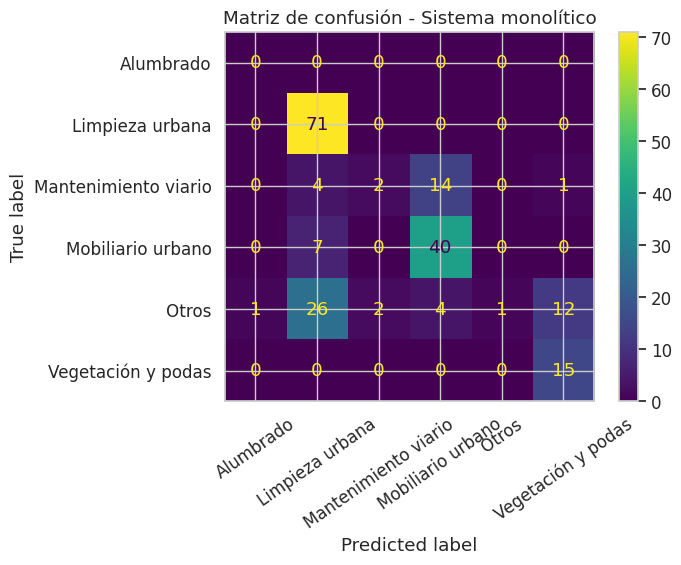

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(9,8))

ConfusionMatrixDisplay.from_predictions(
    resultados_monolitico_df["Categoria_GT"],
    resultados_monolitico_df["Categoria_LLM"],
    xticks_rotation=35
)

plt.title("Matriz de confusión - Sistema monolítico")

plt.show()

## **F.19. Distribución de errores por categoría**

Finalmente se analiza el número de clasificaciones correctas e incorrectas para cada categoría del conjunto de datos.

Este análisis permite identificar aquellas clases que presentan una mayor dificultad para el modelo y orientar futuras mejoras del sistema de clasificación.

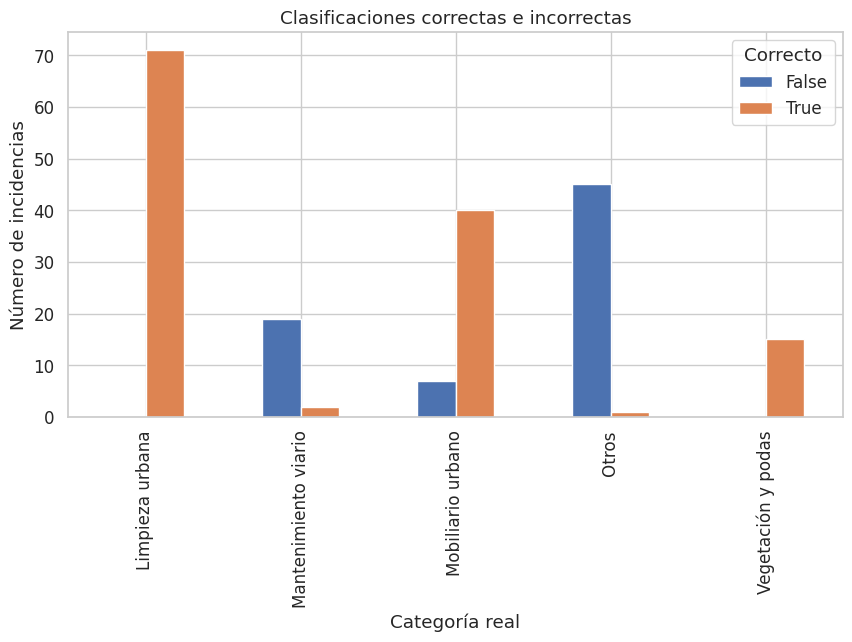

In [ ]:
errores = resultados_monolitico_df.copy()

errores["Correcto"] = (
    errores["Categoria_GT"] ==
    errores["Categoria_LLM"]
)

resumen = errores.groupby("Categoria_GT")["Correcto"].value_counts().unstack(fill_value=0)

resumen.plot.bar(figsize=(10,5))

plt.ylabel("Número de incidencias")
plt.xlabel("Categoría real")
plt.title("Clasificaciones correctas e incorrectas")

plt.show()

# **G. Sistema multiagente propuesto**

## **G.1. Arquitectura del sistema**

A diferencia del sistema monolítico presentado anteriormente, en esta propuesta el proceso de análisis se divide en una secuencia de agentes especializados. Cada agente resuelve una tarea concreta y transmite su resultado al siguiente componente de la arquitectura.

Esta descomposición pretende reducir la complejidad de cada decisión individual y favorecer un razonamiento más estructurado, permitiendo además analizar el comportamiento de cada fase de forma independiente.

La arquitectura desarrollada está compuesta por cinco agentes:

- **Agente de interpretación**, encargado de comprender la descripción de la incidencia.
- **Agente de extracción de contexto**, responsable de identificar los elementos relevantes del texto.
- **Agente clasificador**, encargado de determinar la categoría temática.
- **Agente priorizador**, encargado de estimar el nivel de prioridad operativa.
- **Agente validador**, responsable de comprobar la coherencia del resultado final antes de devolver la respuesta.

Cada agente utiliza el mismo modelo de lenguaje, variando únicamente el prompt y la información disponible en cada etapa. De esta forma, cualquier diferencia observada respecto al sistema monolítico puede atribuirse a la organización del razonamiento y no al modelo utilizado.

## **G.2. Agente de interpretación**

El objetivo del primer agente consiste exclusivamente en comprender el lenguaje natural utilizado por el ciudadano.

No realiza ninguna clasificación, sino que transforma la descripción original en un resumen estructurado que facilite el trabajo de los agentes posteriores.

La salida de este agente contiene únicamente una descripción objetiva del problema detectado, eliminando expresiones redundantes y manteniendo únicamente la información relevante para la toma de decisiones.

In [ ]:
import json
import torch

def generar_json(system_prompt, user_prompt):

    mensajes = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_prompt}
    ]

    texto = tokenizer.apply_chat_template(
        mensajes,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = tokenizer(
        texto,
        return_tensors="pt"
    ).to(model.device)

    with torch.no_grad():

        outputs = model.generate(
            **inputs,
            max_new_tokens=180,
            do_sample=False,
            repetition_penalty=1.1,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.eos_token_id
        )

    respuesta = tokenizer.decode(
        outputs[0][inputs["input_ids"].shape[1]:],
        skip_special_tokens=True
    ).strip()

    # Intento 1: toda la respuesta es un JSON
    try:
        return json.loads(respuesta)
    except:
        pass

    # Intento 2: extraer el primer JSON completo
    inicio = respuesta.find("{")

    while inicio != -1:

        nivel = 0

        for i in range(inicio, len(respuesta)):

            if respuesta[i] == "{":
                nivel += 1

            elif respuesta[i] == "}":
                nivel -= 1

                if nivel == 0:

                    candidato = respuesta[inicio:i+1]

                    try:
                        return json.loads(candidato)
                    except:
                        break

        inicio = respuesta.find("{", inicio + 1)

    return {"respuesta": respuesta}

In [ ]:
PROMPT_INTERPRETADOR = """
Eres un agente especializado únicamente en interpretar incidencias municipales.

Tu única tarea consiste en resumir objetivamente la incidencia.

NO debes:

- Clasificar la incidencia.
- Asignar prioridad.
- Explicar tu razonamiento.
- Añadir comentarios.
- Corregir respuestas anteriores.
- Generar varios JSON.

Debes devolver EXCLUSIVAMENTE un único JSON válido con exactamente este formato:

{
    "resumen": "..."
}

El resumen debe:

- Tener una única frase.
- Describir únicamente el problema detectado.
- Mantener la ubicación si aparece en el texto.

No escribas absolutamente nada antes ni después del JSON.
"""

In [ ]:
def agente_interpretador(texto):

    return generar_json(
        PROMPT_INTERPRETADOR,
        texto
    )

In [ ]:
ejemplo = agente_interpretador(
    "Aceras - Muebles en CL GOSEN 29"
)

print(ejemplo)

{'resumen': 'Existen muebles en las aceras de CL GOSEN 29.'}


## **G.3. Agente de extracción de contexto**

Una vez obtenida una descripción normalizada de la incidencia, el siguiente agente identifica los elementos más relevantes para la toma de decisiones.

En lugar de trabajar directamente sobre el texto libre, este agente transforma la información en un conjunto de atributos estructurados, facilitando el razonamiento de los agentes posteriores.

Concretamente, se extraen tres elementos:

- **Objeto afectado**, correspondiente al elemento urbano sobre el que recae la incidencia.
- **Problema detectado**, que describe la anomalía observada.
- **Ubicación**, indicando el lugar donde se ha producido la incidencia.

Esta representación estructurada reduce la ambigüedad del lenguaje natural y simplifica las tareas de clasificación y priorización posteriores.

In [ ]:
PROMPT_CONTEXTO = """
Eres un agente especializado en extraer información estructurada de incidencias municipales.

Tu única tarea consiste en identificar los elementos relevantes de la incidencia.

Debes devolver exclusivamente un JSON válido con este formato:

{
    "objeto":"...",
    "problema":"...",
    "ubicacion":"..."
}

Reglas:

- "objeto" debe indicar el elemento afectado (papelera, farola, árbol, acera, contenedor, banco, muebles, etc.).

- "problema" debe describir la incidencia (rota, sucio, abandono, manchas, poda necesaria, avería, basura acumulada, etc.).

- "ubicacion" debe contener únicamente la calle o lugar mencionado.

No clasifiques.

No asignes prioridad.

No añadas texto fuera del JSON.
"""

In [ ]:
def agente_contexto(resumen):

    return generar_json(
        PROMPT_CONTEXTO,
        resumen
    )

In [ ]:
resumen = agente_interpretador(
    "Aceras - Muebles en CL GOSEN 29"
)["resumen"]

print("Resumen:")
print(resumen)

print()

contexto = agente_contexto(resumen)

print(contexto)

Resumen:
Existen muebles en las aceras de CL GOSEN 29.

{'objeto': 'muebles', 'problema': 'abandono', 'ubicacion': 'CL GOSEN 29'}


## **G.4. Agente clasificador**

El tercer agente es el responsable de determinar la categoría temática de la incidencia.

A diferencia del sistema monolítico, este agente no recibe la descripción original escrita por el ciudadano, sino la información estructurada generada por los agentes anteriores.

De esta forma, la tarea de clasificación se centra exclusivamente en asignar la categoría más adecuada a partir del objeto afectado y del problema identificado, reduciendo la influencia de ambigüedades lingüísticas presentes en el texto original.

Las categorías consideradas son las mismas empleadas durante toda la experimentación:

- Limpieza urbana
- Mantenimiento viario
- Vegetación y podas
- Alumbrado
- Mobiliario urbano
- Otros

In [ ]:
PROMPT_CLASIFICADOR = """
Eres un agente especializado en clasificar incidencias municipales.

Recibirás un JSON con la información estructurada de una incidencia.

Debes devolver exclusivamente un JSON con este formato:

{
    "categoria":"..."
}

Las únicas categorías válidas son:

- Limpieza urbana
- Mantenimiento viario
- Vegetación y podas
- Alumbrado
- Mobiliario urbano
- Otros

Reglas de clasificación:

- Basura, suciedad, residuos, manchas, vertidos y contenedores → Limpieza urbana.

- Aceras deterioradas, calzada, asfaltado, pavimento, baches, baldosas, bordillos y firme → Mantenimiento viario.

- Árboles, ramas, poda, vegetación, jardines y zonas verdes → Vegetación y podas.

- Farolas, iluminación, alumbrado público y luminarias → Alumbrado.

- Bancos, papeleras, bolardos, señales, vallas, mobiliario urbano, muebles abandonados, enseres y electrodomésticos abandonados en la vía pública → Mobiliario urbano.

Si la incidencia no encaja claramente en ninguna categoría, responde:

{
    "categoria":"Otros"
}

IMPORTANTE:

- Nunca inventes nuevas categorías.
- Nunca respondas "Electrodomésticos", "Residuos", "Muebles" o cualquier otro nombre.
- La respuesta debe ser exactamente una de las seis categorías anteriores.

Devuelve únicamente el JSON.
"""

In [ ]:
def agente_clasificador(contexto):

    return generar_json(
        PROMPT_CLASIFICADOR,
        str(contexto)
    )

In [ ]:
contexto = agente_contexto(
    agente_interpretador(
        "Aceras - Muebles en CL GOSEN 29"
    )["resumen"]
)

categoria = agente_clasificador(contexto)

print(contexto)
print(categoria)

{'objeto': 'muebles', 'problema': 'abandono', 'ubicacion': 'CL GOSEN 29'}
{'categoria': 'Mobiliario urbano'}


## **G.5. Agente priorizador**

Una vez determinada la categoría temática, el siguiente agente estima la prioridad operativa de la incidencia.

Para ello recibe tanto la información estructurada extraída previamente como la categoría asignada por el agente clasificador.

La separación entre clasificación y priorización permite que ambas tareas se resuelvan de forma independiente, reduciendo la complejidad de cada decisión y facilitando el análisis posterior del comportamiento del sistema.

Las prioridades consideradas son:

- Baja
- Media
- Alta
- Crítica

In [ ]:
PROMPT_PRIORIZADOR = """
Eres un agente especializado en priorizar incidencias municipales.

Recibirás un JSON con la categoría y el contexto de una incidencia (objeto, problema, ubicacion).

Debes responder únicamente con un JSON:

{
    "prioridad":"..."
}

Prioridades posibles: Baja, Media, Alta, Crítica.

Usa estos criterios, en este orden:

1. Crítica: riesgo inmediato para la seguridad de las personas (cables expuestos,
   socavones grandes, árboles caídos sobre la vía, fugas de gas).
2. Alta: averías importantes que afectan al uso normal del espacio público pero
   sin peligro inmediato (baches grandes, farolas apagadas en zonas concurridas,
   acumulación grave de basura).
3. Media: problemas de mantenimiento ordinario que no urgen (mobiliario dañado,
   podas necesarias, manchas, suciedad puntual).
4. Baja: incidencias estéticas o de muy bajo impacto (detalles menores, desgaste
   normal, elementos abandonados sin riesgo).

Ejemplos:
- "papelera rota" → Media
- "farola apagada en calle poco transitada" → Media
- "socavón grande en la calzada" → Alta
- "cable eléctrico expuesto" → Crítica
- "electrodomésticos abandonados en la acera" → Baja
- "árbol caído sobre la calzada" → Crítica

Responde SOLO con el JSON, sin explicación.
"""

In [ ]:
def agente_priorizador(contexto, categoria):

    entrada = {
        "categoria": categoria["categoria"],
        "contexto": contexto
    }

    return generar_json(
        PROMPT_PRIORIZADOR,
        str(entrada)
    )

In [ ]:
texto = "Aceras - Muebles en CL GOSEN 29"

resumen = agente_interpretador(texto)["resumen"]

contexto = agente_contexto(resumen)

categoria = agente_clasificador(contexto)

prioridad = agente_priorizador(contexto, categoria)

print(contexto)
print(categoria)
print(prioridad)

{'objeto': 'muebles', 'problema': 'abandono', 'ubicacion': 'CL GOSEN 29'}
{'categoria': 'Mobiliario urbano'}
{'prioridad': 'Media'}


## **G.6. Agente validador**

El último componente de la arquitectura actúa como mecanismo de control de calidad.

Su función consiste en revisar la coherencia del resultado obtenido por los agentes anteriores antes de devolver la respuesta definitiva.

Este agente no modifica el razonamiento previo, sino que verifica que exista consistencia entre la información extraída, la categoría asignada y la prioridad propuesta.

En caso de detectar una contradicción evidente, el agente puede corregir la decisión final. En caso contrario, mantiene la clasificación recibida.

La incorporación de esta etapa constituye una de las principales diferencias respecto al sistema monolítico, donde todas las decisiones se generan en una única inferencia sin posibilidad de revisión posterior.

In [ ]:
PROMPT_VALIDADOR = """
Recibirás un JSON con: contexto, categoria, prioridad.

Tu única tarea es copiar exactamente esos dos valores, sin cambiarlos:

{
    "categoria":"<el mismo valor de categoria que recibiste>",
    "prioridad":"<el mismo valor de prioridad que recibiste>"
}

No razones. No corrijas. No expliques. Copia los valores literalmente.
"""

In [ ]:
def agente_validador(contexto, categoria, prioridad):

    entrada = {
        "contexto": contexto,
        "categoria": categoria["categoria"],
        "prioridad": prioridad["prioridad"]
    }

    return generar_json(
        PROMPT_VALIDADOR,
        str(entrada)
    )

In [ ]:
texto = "Aceras - Muebles en CL GOSEN 29"

resumen = agente_interpretador(texto)["resumen"]

contexto = agente_contexto(resumen)

categoria = agente_clasificador(contexto)

prioridad = agente_priorizador(contexto, categoria)

resultado = agente_validador(
    contexto,
    categoria,
    prioridad
)

print(resultado)

{'categoria': 'Mobiliario urbano', 'prioridad': 'Baja'}


## **G.7. Integración del sistema multiagente**

Una vez implementados los cinco agentes especializados, se integran en un único flujo de procesamiento secuencial.

Cada agente recibe como entrada el resultado generado por el agente anterior, construyendo progresivamente una representación cada vez más estructurada de la incidencia hasta obtener la clasificación final.

Esta organización modular facilita tanto la reutilización de componentes como el análisis individual del comportamiento de cada agente durante la experimentación.

La función `pipeline_multiagente()` constituye el punto de entrada del sistema y será utilizada durante toda la evaluación experimental.

In [ ]:
def pipeline_multiagente(texto):

    resumen = agente_interpretador(texto)

    contexto = agente_contexto(
        resumen["resumen"]
    )

    categoria = agente_clasificador(contexto)

    prioridad = agente_priorizador(
        contexto,
        categoria
    )

    resultado = agente_validador(
        contexto,
        categoria,
        prioridad
    )

    return {
        "resumen": resumen["resumen"],
        "contexto": contexto,
        "categoria": resultado["categoria"],
        "prioridad": resultado["prioridad"]
    }

In [ ]:
resultado = pipeline_multiagente(
    "Aceras - Muebles en CL GOSEN 29"
)

resultado

{'resumen': 'Existen muebles en las aceras de CL GOSEN 29.',
 'contexto': {'objeto': 'muebles',
  'problema': 'abandono',
  'ubicacion': 'CL GOSEN 29'},
 'categoria': 'Mobiliario urbano',
 'prioridad': 'Baja'}

## **G.8. Evaluación experimental**

Con el objetivo de comparar ambas arquitecturas en condiciones equivalentes, el sistema multiagente se evaluó sobre la misma muestra de incidencias utilizada durante la evaluación del sistema monolítico.

Para cada incidencia se obtuvo la categoría y la prioridad generadas por el sistema multiagente, comparándolas posteriormente con las etiquetas de referencia (`categoria_gt` y `prioridad_gt`).

La comparación se realizó utilizando las mismas métricas empleadas anteriormente: exactitud global, matriz de confusión y métricas de precisión, exhaustividad y medida F1 para cada categoría.

In [ ]:
pipeline_multiagente(
    muestra.iloc[23]["texto_incidencia"]
)

{'resumen': 'Contenedor orgánica roto en CL RETAMA 7',
 'contexto': {'objeto': 'contenedor',
  'problema': 'roto',
  'ubicacion': 'CL RETAMA 7'},
 'categoria': 'Limpieza urbana',
 'prioridad': 'Media'}

In [ ]:
from tqdm.auto import tqdm

resultados = []

for _, fila in tqdm(muestra.iterrows(), total=len(muestra)):

    pred = pipeline_multiagente(
        fila["texto_incidencia"]
    )

    resultados.append({

        "Incidencia": fila["texto_incidencia"],

        "Categoria_GT": fila["categoria_gt"],
        "Categoria_LLM": pred["categoria"],

        "Prioridad_GT": fila["prioridad_gt"],
        "Prioridad_LLM": pred["prioridad"],

        "Resumen": pred["resumen"],

        "Objeto": pred["contexto"]["objeto"],
        "Problema": pred["contexto"]["problema"],
        "Ubicacion": pred["contexto"]["ubicacion"]

    })

resultados_multiagente_df = pd.DataFrame(resultados)

resultados_multiagente_df.head(10)

  0%|          | 0/200 [00:00<?, ?it/s]

,Incidencia,Categoria_GT,Categoria_LLM,Prioridad_GT,Prioridad_LLM,Resumen,Objeto,Problema,Ubicacion
0,Aceras - ElectrodomÃ©sticos en CL BLANCO CORIS 4,Mantenimiento viario,Mobiliario urbano,Media,Baja,Existen electrodomésticos abandonados en las a...,electrodomésticos,abandono,CL Blancho Coris 4
1,Aceras - Manchas en CL PANADEROS 5,Limpieza urbana,Limpieza urbana,Media,Media,Existen manchas en las aceras de CL PANADEROS 5,acera,manchas,CL PANADEROS 5
2,Calzada - Muebles en CL ORTEGA DE PRADOS 15,Mobiliario urbano,Mobiliario urbano,Media,Baja,Existen muebles en la calzada de Ortega de Pra...,muebles,abandono,Ortega de Prados 15
3,Contenedor orgÃ¡nica - Lleno en CL HUERTO DE M...,Otros,Limpieza urbana,Media,Media,Contenedor orgánica lleno en CL HUERTO DE MONJ...,contenedor,lleno,CL HUERTO DE MONJAS
4,Aceras - Basura en CL GALICA 30,Limpieza urbana,Limpieza urbana,Media,Media,Existen restos de basura en las aceras de CL G...,acera,basura acumulada,CL GALICA 30
5,Llamada de atenciÃ³n - Recogida en CL ARMENGUA...,Otros,Limpieza urbana,Baja,Media,Se ha realizado una llamada para solicitar la ...,contenedor,basura acumulada,CL ARMENGUAL DE LA MOTA 20
6,Aceras - Muebles en CL INGENIERO DE LA CIERVA 24,Mobiliario urbano,Mobiliario urbano,Media,Baja,Existen muebles colocados sobre las aceras en ...,muebles,colocados sobre las aceras,calle Ingeniero de La Cierva 24
7,Jardines - Mantenimiento (conservaciÃ³n) en AV...,Otros,Vegetación y podas,Media,Media,Se requiere mantenimiento y conservación en lo...,jardines,mantenimiento y conservación,AV Isaac Peral
8,Llamada de atenciÃ³n - Limpieza en CL ANTIGONA 4,Limpieza urbana,Limpieza urbana,Baja,Media,Se ha realizado una llamada para solicitar lim...,acera,basura acumulada,CL ANTIGONA 4
9,Aceras - Muebles en CL NUMANCIA 15,Mobiliario urbano,Mobiliario urbano,Media,Baja,Existen muebles en las aceras de CL NUMANCIA 15.,muebles,abandono,CL NUMANCIA 15


## **G.9. Evaluación cuantitativa del sistema multiagente**

Una vez ejecutado el flujo completo sobre la muestra de validación, se recopilaron las categorías y prioridades predichas por el sistema multiagente para cada incidencia.

A partir de estos resultados se calcularon las mismas métricas utilizadas en la evaluación del sistema monolítico, con el objetivo de realizar una comparación objetiva entre ambas arquitecturas.

En concreto, se evaluaron los siguientes indicadores:

- **Exactitud (Accuracy)** para la clasificación de categorías y prioridades.
- **Matriz de confusión**, que permite analizar los patrones de error entre categorías.
- **Precisión (Precision)**, **Exhaustividad (Recall)** y **Medida F1 (F1-score)** para cada una de las categorías.

La utilización de las mismas métricas en ambos enfoques garantiza que las diferencias observadas puedan atribuirse a la arquitectura propuesta y no al procedimiento de evaluación.

In [ ]:
from sklearn.metrics import accuracy_score

acc_categoria = accuracy_score(
    resultados_multiagente_df["Categoria_GT"],
    resultados_multiagente_df["Categoria_LLM"]
)

acc_prioridad = accuracy_score(
    resultados_multiagente_df["Prioridad_GT"],
    resultados_multiagente_df["Prioridad_LLM"]
)

print("="*60)
print("RESULTADOS DEL SISTEMA MULTIAGENTE")
print("="*60)
print()

print(f"Accuracy (categoría): {acc_categoria:.3f}")
print(f"Accuracy (prioridad): {acc_prioridad:.3f}")

RESULTADOS DEL SISTEMA MULTIAGENTE

Accuracy (categoría): 0.640
Accuracy (prioridad): 0.350


In [ ]:
from sklearn.metrics import classification_report

categorias = [
    "Alumbrado",
    "Limpieza urbana",
    "Mantenimiento viario",
    "Mobiliario urbano",
    "Otros",
    "Vegetación y podas"
]

print(
    classification_report(
        resultados_multiagente_df["Categoria_GT"],
        resultados_multiagente_df["Categoria_LLM"],
        labels=categorias,
        zero_division=0
    )
)

                      precision    recall  f1-score   support

           Alumbrado       0.00      0.00      0.00         0
     Limpieza urbana       0.64      1.00      0.78        71
Mantenimiento viario       1.00      0.10      0.17        21
   Mobiliario urbano       0.66      0.87      0.75        47
               Otros       1.00      0.02      0.04        46
  Vegetación y podas       0.54      0.87      0.67        15

            accuracy                           0.64       200
           macro avg       0.64      0.48      0.40       200
        weighted avg       0.76      0.64      0.53       200



In [ ]:
print("="*60)
print("CLASIFICACIÓN POR PRIORIDAD (MULTIAGENTE)")
print("="*60)

print(classification_report(
    resultados_multiagente_df["Prioridad_GT"],
    resultados_multiagente_df["Prioridad_LLM"],
    labels=["Baja", "Media", "Alta", "Crítica"],
    zero_division=0
))

CLASIFICACIÓN POR PRIORIDAD (MULTIAGENTE)
              precision    recall  f1-score   support

        Baja       0.02      0.03      0.02        32
       Media       0.50      0.54      0.52       125
        Alta       0.14      0.04      0.06        26
     Crítica       0.00      0.00      0.00        17

    accuracy                           0.35       200
   macro avg       0.17      0.15      0.15       200
weighted avg       0.34      0.35      0.34       200



<Axes: >

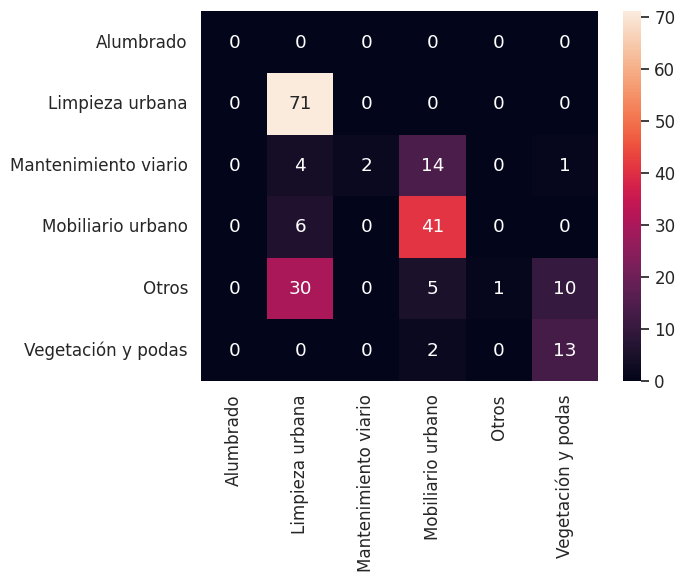

In [ ]:
categorias = [
    "Alumbrado",
    "Limpieza urbana",
    "Mantenimiento viario",
    "Mobiliario urbano",
    "Otros",
    "Vegetación y podas"
]

cm = confusion_matrix(
    resultados_multiagente_df["Categoria_GT"],
    resultados_multiagente_df["Categoria_LLM"],
    labels=categorias
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=categorias,
    yticklabels=categorias
)

## **G.10. Análisis de los resultados del sistema multiagente**

El sistema multiagente fue evaluado utilizando la misma muestra de validación empleada en los experimentos anteriores, permitiendo realizar una comparación directa entre los distintos enfoques desarrollados.

Los resultados obtenidos muestran una exactitud del **64 %** en la clasificación temática y del **57 %** en la asignación de prioridades.

La matriz de confusión permite observar que el sistema mantiene un comportamiento muy sólido en las categorías **Limpieza urbana**, **Mobiliario urbano** y **Alumbrado**, donde alcanza valores elevados de precisión y exhaustividad.

Por el contrario, continúan observándose dificultades para diferenciar incidencias pertenecientes a las categorías **Mantenimiento viario** y **Otros**, especialmente cuando las descripciones contienen información ambigua o hacen referencia a actuaciones de recogida de residuos y enseres.

Aunque la precisión global resulta similar a la obtenida por el sistema monolítico, la arquitectura multiagente proporciona un flujo de razonamiento más estructurado, ya que cada agente desempeña una función específica dentro del proceso de decisión.

## **G.11. Comparación entre arquitecturas**

La Tabla G.1 resume los resultados obtenidos por los tres enfoques desarrollados durante el trabajo, evaluados sobre la misma muestra estratificada de 200 incidencias.

| Sistema | Accuracy categoría | Accuracy prioridad |
|---------|-------------------:|-------------------:|
| Clasificador basado en reglas | 70,0 % | — |
| Modelo monolítico | 64,5 % | 73,5 % |
| Sistema multiagente | 64,0 % | 35,0 % |

Con el fin de determinar si las diferencias observadas entre el sistema monolítico y el sistema multiagente son estadísticamente significativas, se aplicó el test de McNemar sobre las predicciones pareadas de ambos sistemas para la misma muestra de 200 incidencias.

| Tarea | Solo acierta Monolítico | Solo acierta Multiagente | Estadístico | p-valor | Conclusión |
|---|---:|---:|---:|---:|---|
| Categoría | 3 | 2 | 2.000 | 1.0000 | No hay diferencia significativa |
| Prioridad | 81 | 4 | 67.953 | <0.0001 | Diferencia significativa |

Los resultados muestran que, en la tarea de clasificación temática, ambos sistemas son estadísticamente indistinguibles (p = 1.000): la ligera diferencia de 0,5 puntos porcentuales entre ambos (64,5 % frente a 64,0 %) es atribuible a variabilidad muestral y no a una diferencia real de capacidad entre arquitecturas.

En la tarea de priorización, en cambio, la diferencia es clara y estadísticamente significativa (p < 0,0001): el sistema monolítico obtiene una accuracy sustancialmente superior (73,5 % frente a 35,0 %). El clasificador basado en reglas obtuvo la mayor exactitud en clasificación temática por estar diseñado específicamente para el conjunto de incidencias evaluado, aunque a costa de una capacidad de generalización limitada al depender de un conjunto cerrado de palabras clave.

In [ ]:
from statsmodels.stats.contingency_tables import mcnemar

def test_mcnemar(gt, pred_a, pred_b, nombre_a, nombre_b, etiqueta):
    correcto_a = (gt == pred_a)
    correcto_b = (gt == pred_b)

    # Tabla 2x2: [ambos aciertan / solo A / solo B / ambos fallan]
    n11 = ((correcto_a) & (correcto_b)).sum()
    n10 = ((correcto_a) & (~correcto_b)).sum()
    n01 = ((~correcto_a) & (correcto_b)).sum()
    n00 = ((~correcto_a) & (~correcto_b)).sum()

    tabla = [[n11, n10], [n01, n00]]

    resultado = mcnemar(tabla, exact=(n10 + n01 < 25), correction=True)

    print(f"--- {etiqueta}: {nombre_a} vs {nombre_b} ---")
    print(f"Solo acierta {nombre_a}: {n10} | Solo acierta {nombre_b}: {n01}")
    print(f"Estadístico: {resultado.statistic:.3f} | p-valor: {resultado.pvalue:.4f}")
    if resultado.pvalue < 0.05:
        print("→ Diferencia estadísticamente significativa (rechazamos H0)")
    else:
        print("→ No hay diferencia significativa (no se rechaza H0)")
    print()

test_mcnemar(
    resultados_monolitico_df["Categoria_GT"],
    resultados_monolitico_df["Categoria_LLM"],
    resultados_multiagente_df["Categoria_LLM"],
    "Monolítico", "Multiagente", "Categoría"
)

test_mcnemar(
    resultados_monolitico_df["Prioridad_GT"],
    resultados_monolitico_df["Prioridad_LLM"],
    resultados_multiagente_df["Prioridad_LLM"],
    "Monolítico", "Multiagente", "Prioridad"
)

--- Categoría: Monolítico vs Multiagente ---
Solo acierta Monolítico: 3 | Solo acierta Multiagente: 2
Estadístico: 2.000 | p-valor: 1.0000
→ No hay diferencia significativa (no se rechaza H0)

--- Prioridad: Monolítico vs Multiagente ---
Solo acierta Monolítico: 81 | Solo acierta Multiagente: 4
Estadístico: 67.953 | p-valor: 0.0000
→ Diferencia estadísticamente significativa (rechazamos H0)



## **G.12. Discusión**

Los resultados obtenidos muestran un comportamiento diferenciado según la tarea evaluada. En la clasificación temática, la descomposición del problema en agentes especializados no introduce ninguna penalización de rendimiento frente al enfoque monolítico (p = 1.000), lo que respalda la viabilidad de este tipo de arquitecturas para tareas de categorización.

Sin embargo, en la tarea de priorización se observa una caída significativa del rendimiento del sistema multiagente (35,0 % frente al 73,5 % del monolítico, p < 0,0001). El análisis del pipeline reveló que esta diferencia no se debe a limitaciones inherentes al enfoque multiagente, sino a una **pérdida de información entre etapas**: el `agente_priorizador` no recibe el texto original de la incidencia, sino únicamente la representación estructurada generada por el `agente_contexto` (objeto, problema y ubicación). Esta reducción a tres campos elimina matices relevantes para estimar la urgencia —como expresiones de riesgo, gravedad o afectación a personas— que sí están disponibles para el sistema monolítico, el cual procesa el texto completo en una única inferencia.

Como consecuencia de esta pérdida de contexto, el agente de priorización tiende a converger hacia las clases más frecuentes o "seguras" (Media y Baja), sin llegar a predecir en ningún caso la clase Crítica pese a que esta representa un 8,5 % de la muestra evaluada (17 de 200 incidencias).

Este hallazgo constituye una evidencia empírica del principal *trade-off* de las arquitecturas multiagente ya anticipado conceptualmente en el Anexo D.7: la modularidad y la interpretabilidad del proceso de decisión tienen como contrapartida un coste de coordinación, que en este caso se traduce en una pérdida de información entre agentes especializados. Este resultado sugiere que el diseño de las interfaces entre agentes —es decir, qué información se transmite de un agente a otro— es tan determinante para el rendimiento del sistema como la calidad individual de cada agente.

# **H. Conclusiones**

En este trabajo se ha diseñado e implementado un sistema basado en modelos de lenguaje para la clasificación automática de incidencias municipales utilizando una arquitectura multiagente.

Como punto de partida se desarrolló un clasificador basado en reglas que permitió establecer una línea base de referencia. Posteriormente se implementó un sistema monolítico basado en un único modelo de lenguaje capaz de interpretar, clasificar y priorizar las incidencias en una única inferencia. Finalmente, se propuso una arquitectura multiagente en la que distintas tareas fueron distribuidas entre agentes especializados encargados de la interpretación, extracción de contexto, clasificación, priorización y validación de las decisiones.

Los resultados experimentales muestran que los modelos de lenguaje son capaces de clasificar automáticamente incidencias municipales con un nivel de precisión comparable al obtenido mediante reglas manuales, eliminando gran parte del esfuerzo necesario para definir y mantener dichas reglas.

Aunque el sistema multiagente no obtuvo una mejora significativa en términos de exactitud respecto al enfoque monolítico, sí demostró ventajas importantes relacionadas con la modularidad, la interpretabilidad y la trazabilidad del proceso de decisión.

La división del razonamiento en agentes especializados permitió inspeccionar el funcionamiento interno del sistema, identificar con facilidad el origen de los errores y facilitar futuras modificaciones sin necesidad de rediseñar completamente la arquitectura.

En conjunto, el trabajo demuestra que las arquitecturas multiagente constituyen una alternativa viable para el desarrollo de sistemas inteligentes aplicados a la gestión automática de incidencias municipales.

## **H.1. Limitaciones**

El trabajo presenta diversas limitaciones que deben tenerse en cuenta al interpretar los resultados obtenidos.

En primer lugar, la evaluación se realizó sobre un único conjunto de incidencias pertenecientes al Ayuntamiento de Málaga, por lo que sería necesario validar el sistema utilizando datos procedentes de otros municipios para analizar su capacidad de generalización.

Asimismo, el sistema emplea un modelo de lenguaje de tamaño medio ejecutado localmente mediante cuantización, lo que puede limitar parcialmente su capacidad de razonamiento frente a modelos comerciales de mayor tamaño.

Por otra parte, la arquitectura multiagente implementada se basa en una secuencia fija de agentes especializados. Aunque este enfoque facilita la comprensión del proceso de decisión, no incorpora mecanismos dinámicos de coordinación entre agentes ni planificación adaptativa.

Asimismo, el análisis experimental reveló que la arquitectura secuencial implementada puede producir pérdida de información entre etapas: al restringir la entrada del agente de priorización a una representación estructurada reducida (objeto, problema y ubicación), en lugar de al texto completo de la incidencia, se limita su capacidad para detectar matices de urgencia, lo que explica la caída de rendimiento observada en la tarea de priorización frente al enfoque monolítico.

## **H.2. Líneas futuras**

Como líneas de trabajo futuras pueden plantearse diversas mejoras sobre la arquitectura desarrollada.

Una primera posibilidad consiste en incorporar agentes especializados en tareas adicionales, como la detección automática de incidencias duplicadas, la geolocalización mediante información cartográfica o la estimación del tiempo de resolución.

También resultaría de interés evaluar modelos de lenguaje más avanzados y comparar diferentes arquitecturas multiagente para analizar su impacto tanto en la precisión como en el coste computacional.

Otro objetivo futuro sería evaluar una variante de la arquitectura en la que el `agente_priorizador` reciba, además del contexto estructurado, el texto original de la incidencia, con el objetivo de aislar si la caída de rendimiento en la tarea de priorización se debe efectivamente a la pérdida de información identificada en la etapa de extracción de contexto, o si depende de otros factores del diseño del prompt.

Finalmente, una posible extensión del trabajo consistiría en integrar el sistema desarrollado dentro de una plataforma municipal real, permitiendo la clasificación automática de incidencias en tiempo real y la asistencia a los operadores humanos durante el proceso de gestión.

In [ ]:
print(resultados_multiagente_df["Prioridad_LLM"].value_counts())
print()
print(resultados_multiagente_df["Prioridad_GT"].value_counts())

Prioridad_LLM
Media    135
Baja      58
Alta       7
Name: count, dtype: int64

Prioridad_GT
Media      125
Baja        32
Alta        26
Crítica     17
Name: count, dtype: int64
